# Band Gap Prediction — Complete Analysis Framework

**Models:** Ridge, Lasso, Random Forest, Gradient Boosting, XGBoost  
**Dataset:** Materials Project band gaps via `matminer`  
**Features:** 132 Magpie compositional features → engineered sets  
**Target:** Band gap (eV) — regression

---

## Notebook Structure

| Section | Content |
|---|---|
| 1 | Install & Imports |
| 2 | Load & Featurize Dataset |
| 3 | EDA — Distribution, Correlations, Class Split |
| 4 | Feature Selection Pipeline (diagnostics at each step) |
| 5 | Feature Engineering + Set Assembly |
| 6 | Baseline Models (all models × all feature sets) |
| 7 | Learning Curve Analysis (dataset size effect) |
| 8 | Ridge — Hyperparameter Tuning Session |
| 9 | Lasso — Hyperparameter Tuning Session |
| 10 | Random Forest — Hyperparameter Tuning Session |
| 11 | Gradient Boosting — Hyperparameter Tuning Session |
| 12 | XGBoost — Hyperparameter Tuning Session |
| 13 | SHAP Analysis |
| 14 | Final Summary & Insights |

---
## 1. Install & Imports

In [ ]:
!pip install matminer pymatgen scikit-learn pandas numpy matplotlib seaborn xgboost optuna shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 838.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

def get_metrics(y_true, y_pred, label=''):
    return {'label': label, 'MAE': round(mean_absolute_error(y_true, y_pred), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            'R2': round(r2_score(y_true, y_pred), 4)}

def fit_eval(model, Xtr, ytr, Xte, yte, label=''):
    model.fit(Xtr, ytr)
    tr_m = get_metrics(ytr, model.predict(Xtr), label + '_train')
    te_m = get_metrics(yte, model.predict(Xte), label + '_test')
    overfit_gap = round(tr_m['MAE'] - te_m['MAE'], 4)
    return model, tr_m, te_m, overfit_gap

print('All imports successful.')

All imports successful.


---
## 2. Load & Featurize Dataset

> **Note:** Featurization takes ~5-10 min. Results are cached to Google Drive so it only runs once.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
CACHE_PATH = '/content/drive/MyDrive/ML Project/df_featurized.parquet'

ep_feat = ElementProperty.from_preset('magpie')
feature_cols = ep_feat.feature_labels()

if os.path.exists(CACHE_PATH):
    df = pd.read_parquet(CACHE_PATH)
    print(f'Loaded from cache: {df.shape}')
else:
    print('Generating 132 Magpie features (~5-10 min)...')
    df = load_dataset('matbench_mp_gap')
    df = df.rename(columns={'gap pbe': 'band_gap'})
    df['composition_str'] = df['structure'].apply(lambda x: str(x.composition))
    stc = StrToComposition(target_col_id='composition_obj')
    df  = stc.featurize_dataframe(df, col_id='composition_str', ignore_errors=True)
    df  = ep_feat.featurize_dataframe(df, col_id='composition_obj', ignore_errors=True)
    df_save = df.drop(columns=[c for c in ['structure','composition','composition_obj'] if c in df.columns])
    df_save.to_parquet(CACHE_PATH)
    df = df_save
    print(f'Done. Saved to {CACHE_PATH}')

print(f'Feature columns: {len(feature_cols)}')
print(df['band_gap'].describe())

Loaded from cache: (106113, 134)
Feature columns: 132
count    106113.000000
mean          1.214627
std           1.598966
min           0.000000
25%           0.000000
50%           0.273800
75%           2.207500
max           9.721200
Name: band_gap, dtype: float64


In [ ]:
df_clean = df[feature_cols + ['band_gap']].dropna()
print(f'Samples after dropping NaN: {len(df_clean)} (removed {len(df)-len(df_clean)})')
#df_clean = df_clean[df_clean['band_gap'] > 0.5]
X_raw = df_clean[feature_cols].values.astype(np.float32)
y     = df_clean['band_gap'].values.astype(np.float32)
print(X_raw.shape[0])
# 70 / 15 / 15 split
X_temp, X_test_raw, y_temp, y_test = train_test_split(X_raw, y, test_size=0.15, random_state=42)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.17647, random_state=42)

"""X_temp, X_test_raw, y_temp, y_test = train_test_split(X_raw, y, test_size=0.086989804, random_state=42)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.09527802, random_state=42)
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_train_raw, y_train, test_size=0.4733999239, random_state=42)"""

print(f'Train: {X_train_raw.shape[0]:,} | Val: {X_val_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}')

base_scaler = StandardScaler()
X_train_sc  = base_scaler.fit_transform(X_train_raw)
X_val_sc    = base_scaler.transform(X_val_raw)
X_test_sc   = base_scaler.transform(X_test_raw)

Samples after dropping NaN: 106113 (removed 0)
106113
Train: 74,279 | Val: 15,917 | Test: 15,917


---
## 3. EDA

### 3A — Band Gap Distribution

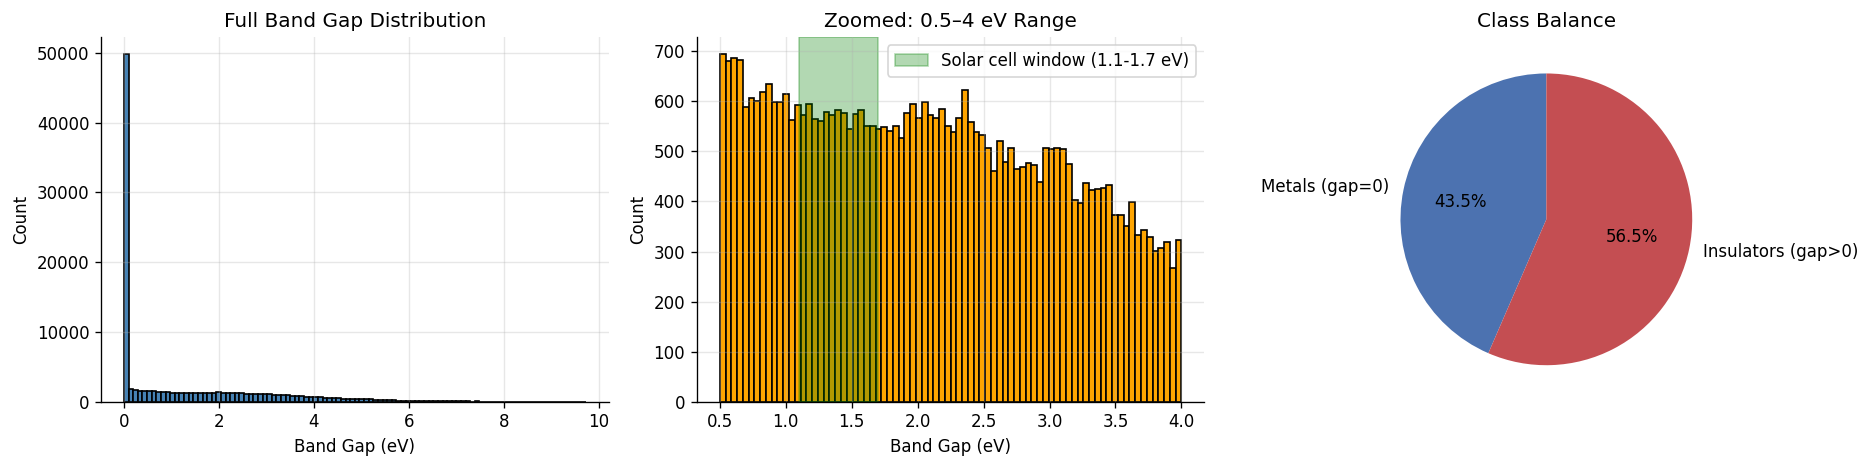

Solar cell candidates: 7795 (7.3%)
Metals (gap=0): 46151 (43.5%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Band gap distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
axes[0].hist(y, bins=100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Band Gap (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Full Band Gap Distribution')

# Zoomed into solar cell region
axes[1].hist(y[(y >= 0.5) & (y <= 4)], bins=80, color='orange', edgecolor='black')
axes[1].axvspan(1.1, 1.7, alpha=0.3, color='green', label='Solar cell window (1.1-1.7 eV)')
axes[1].set_xlabel('Band Gap (eV)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoomed: 0.5–4 eV Range')
axes[1].legend()

metals = (y == 0).sum(); insulators = (y > 0).sum()
axes[2].pie([metals, insulators], labels=['Metals (gap=0)', 'Insulators (gap>0)'],
            colors=[COLORS[0], COLORS[2]], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Class Balance')

plt.tight_layout()
plt.show()

# Count solar cell candidates
solar_candidates = y[(y >= 1.1) & (y <= 1.7)]
print(f"Solar cell candidates: {len(solar_candidates)} ({len(solar_candidates)/len(y)*100:.1f}%)")
print(f"Metals (gap=0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")

### 3B — Feature-Target Linear Correlation (Top 30)

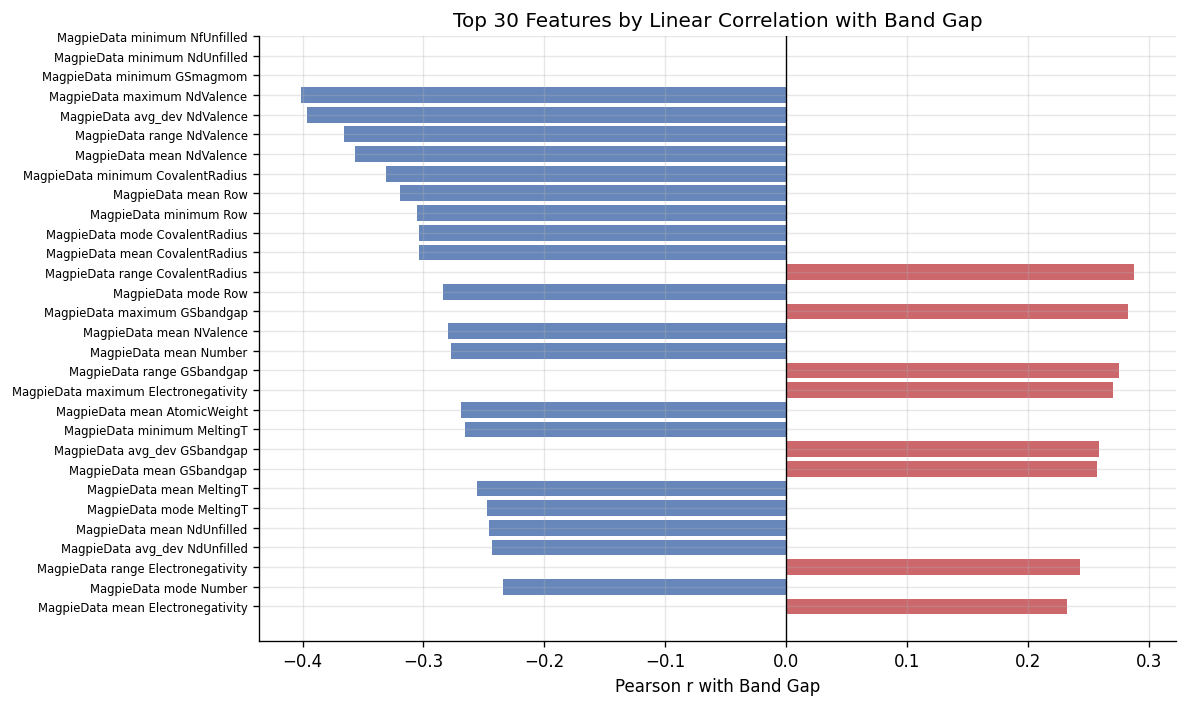

Features with low |r| may still be useful — MI (Section 4C) captures non-linear relationships.


In [ ]:
corr_with_target = np.array([
    np.corrcoef(X_train_raw[:, i], y_train)[0, 1] for i in range(X_train_raw.shape[1])
])
top30_idx = np.argsort(np.abs(corr_with_target))[::-1][:30]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#C44E52' if c > 0 else '#4C72B0' for c in corr_with_target[top30_idx]]
ax.barh(range(30), corr_with_target[top30_idx][::-1], color=colors_bar[::-1], alpha=0.85)
ax.set_yticks(range(30))
ax.set_yticklabels([feature_cols[i] for i in top30_idx][::-1], fontsize=7)
ax.set_xlabel('Pearson r with Band Gap')
ax.set_title('Top 30 Features by Linear Correlation with Band Gap')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

print('Features with low |r| may still be useful — MI (Section 4C) captures non-linear relationships.')

---
## 4. Feature Selection Pipeline

We track model performance at every step so we know if a step is actually helping.

> Variance filter is applied on **raw (unscaled)** features. Applying it post-scaling makes it useless since StandardScaler normalizes all variances to ~1.

In [ ]:
# Quick diagnostic eval — Ridge + XGBoost at each step
def quick_eval(Xtr, ytr, Xte, yte, label):
    r   = Ridge(alpha=1.0)
    xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                       tree_method='hist', random_state=42, verbosity=0)
    r.fit(Xtr, ytr); xgb.fit(Xtr, ytr)
    r_mae   = mean_absolute_error(yte, r.predict(Xte))
    xgb_mae = mean_absolute_error(yte, xgb.predict(Xte))
    print(f'{label:38s} | n={Xtr.shape[1]:4d} | Ridge={r_mae:.4f} | XGB={xgb_mae:.4f}')
    return r_mae, xgb_mae

selection_log = []
r_mae, x_mae = quick_eval(X_train_sc, y_train, X_val_sc, y_val, 'Raw 132 features')
selection_log.append({'stage': 'Raw', 'n_features': 132, 'ridge_mae': r_mae, 'xgb_mae': x_mae})

Raw 132 features                       | n= 132 | Ridge=0.8247 | XGB=0.5463


### 4A — Variance Threshold (on raw features)

Before: 132 | After: 112 | Removed: 20
After variance filter (raw)            | n= 112 | Ridge=0.8272 | XGB=0.5480


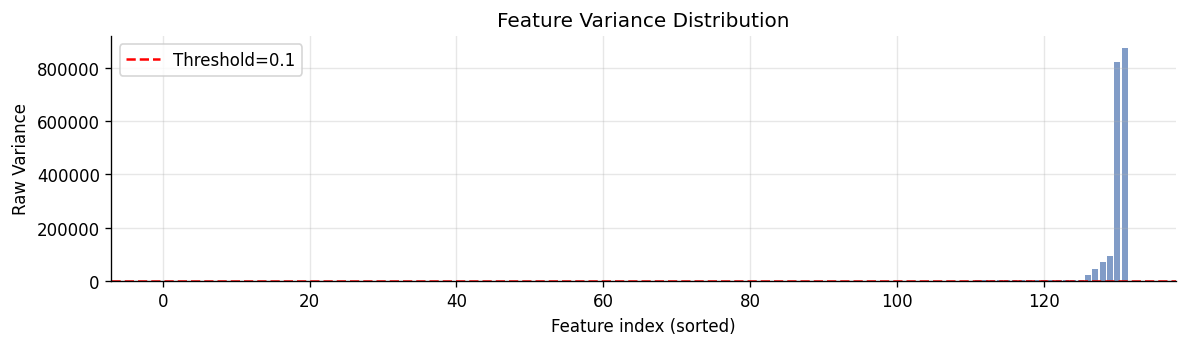

In [ ]:
VAR_THRESHOLD = 0.1
vt = VarianceThreshold(threshold=VAR_THRESHOLD)
vt.fit(X_train_raw)  # raw, not scaled
mask_var = vt.get_support()
feature_cols_var = [feature_cols[i] for i, m in enumerate(mask_var) if m]

X_train_v = X_train_sc[:, mask_var]
X_val_v   = X_val_sc[:, mask_var]
X_test_v  = X_test_sc[:, mask_var]

print(f'Before: {X_train_sc.shape[1]} | After: {mask_var.sum()} | Removed: {(~mask_var).sum()}')
r_mae, x_mae = quick_eval(X_train_v, y_train, X_val_v, y_val, 'After variance filter (raw)')
selection_log.append({'stage': 'Variance', 'n_features': int(mask_var.sum()), 'ridge_mae': r_mae, 'xgb_mae': x_mae})

raw_variances = np.var(X_train_raw, axis=0)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(raw_variances)), np.sort(raw_variances), color=COLORS[0], alpha=0.7)
ax.axhline(VAR_THRESHOLD, color='red', linestyle='--', label=f'Threshold={VAR_THRESHOLD}')
ax.set_xlabel('Feature index (sorted)'); ax.set_ylabel('Raw Variance')
ax.set_title('Feature Variance Distribution'); ax.legend(); plt.tight_layout(); plt.show()

### 4B — Correlation Filter (compare 3 thresholds)

In [ ]:
def correlation_filter(Xtr, Xvl, Xte, feat_names, threshold):
    corr_matrix = np.corrcoef(Xtr.T)
    upper_tri   = np.triu(np.abs(corr_matrix), k=1)
    cols_drop   = {c for c in range(upper_tri.shape[1]) if any(upper_tri[:c, c] > threshold)}
    mask        = np.array([i not in cols_drop for i in range(Xtr.shape[1])])
    return Xtr[:, mask], Xvl[:, mask], Xte[:, mask], [feat_names[i] for i, m in enumerate(mask) if m], mask

print('Testing correlation thresholds — pick the one where XGB MAE stops improving:')
for thr in [0.85, 0.90, 0.95]:
    Xt, Xv, _, _, _ = correlation_filter(X_train_v, X_val_v, X_test_v, feature_cols_var, thr)
    quick_eval(Xt, y_train, Xv, y_val, f'Corr threshold={thr}')

CORR_THRESHOLD = 0.85  # CHANGE THIS based on results above
X_train_c, X_val_c, X_test_c, feature_cols_corr, _ = \
    correlation_filter(X_train_v, X_val_v, X_test_v, feature_cols_var, CORR_THRESHOLD)
r_mae, x_mae = quick_eval(X_train_c, y_train, X_val_c, y_val, f'Final corr={CORR_THRESHOLD}')
selection_log.append({'stage': 'Correlation', 'n_features': X_train_c.shape[1], 'ridge_mae': r_mae, 'xgb_mae': x_mae})
print(f'Using threshold {CORR_THRESHOLD} → {X_train_c.shape[1]} features')

Testing correlation thresholds — pick the one where XGB MAE stops improving:
Corr threshold=0.85                    | n=  64 | Ridge=0.8623 | XGB=0.5540
Corr threshold=0.9                     | n=  74 | Ridge=0.8569 | XGB=0.5523
Corr threshold=0.95                    | n=  88 | Ridge=0.8496 | XGB=0.5487
Final corr=0.85                        | n=  64 | Ridge=0.8623 | XGB=0.5540
Using threshold 0.85 → 64 features


### 4C — Mutual Information (cross-validate top-K)

Computing MI on 20,000 samples...
Done.

Testing MI top-K values — look for the K where XGB MAE flattens:
MI top-K=20                            | n=  20 | Ridge=0.9827 | XGB=0.5965
MI top-K=30                            | n=  30 | Ridge=0.9228 | XGB=0.5764
MI top-K=40                            | n=  40 | Ridge=0.8833 | XGB=0.5651
MI top-K=50                            | n=  50 | Ridge=0.8741 | XGB=0.5620
MI top-K=60                            | n=  60 | Ridge=0.8655 | XGB=0.5552
MI top-K=80                            | n=  64 | Ridge=0.8623 | XGB=0.5540


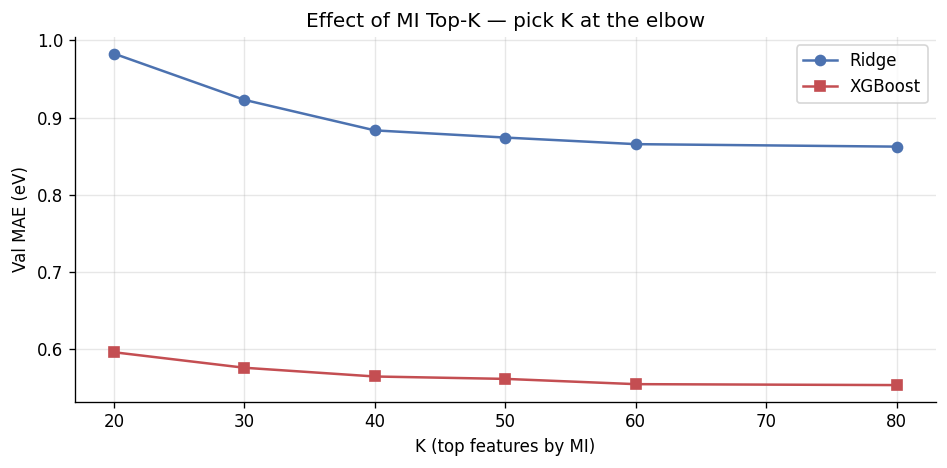


Auto-selected K = 80. Change manually below if the curve suggests otherwise.


In [ ]:
N_SUB = 20_000
idx_sub = np.random.choice(len(X_train_c), size=min(N_SUB, len(X_train_c)), replace=False)
print(f'Computing MI on {len(idx_sub):,} samples...')
mi_scores = mutual_info_regression(X_train_c[idx_sub], y_train[idx_sub], random_state=42)
print('Done.')

mi_df = pd.DataFrame({'feature': feature_cols_corr, 'mi_score': mi_scores})\
          .sort_values('mi_score', ascending=False).reset_index(drop=True)

print('\nTesting MI top-K values — look for the K where XGB MAE flattens:')
K_results = {}
for k in [20, 30, 40, 50, 60, 80]:
    k_feats = mi_df.head(min(k, len(mi_df)))['feature'].tolist()
    mask_k  = np.array([f in k_feats for f in feature_cols_corr])
    r_m, x_m = quick_eval(X_train_c[:, mask_k], y_train, X_val_c[:, mask_k], y_val, f'MI top-K={k}')
    K_results[k] = {'ridge': r_m, 'xgb': x_m}

ks = list(K_results.keys())
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, [K_results[k]['ridge'] for k in ks], 'o-', color=COLORS[0], label='Ridge')
ax.plot(ks, [K_results[k]['xgb']   for k in ks], 's-', color=COLORS[2], label='XGBoost')
ax.set_xlabel('K (top features by MI)'); ax.set_ylabel('Val MAE (eV)')
ax.set_title('Effect of MI Top-K — pick K at the elbow')
ax.legend(); plt.tight_layout(); plt.show()

K_MI = min(K_results, key=lambda k: K_results[k]['xgb'])
print(f'\nAuto-selected K = {K_MI}. Change manually below if the curve suggests otherwise.')

After MI top-60                        | n=  60 | Ridge=0.8655 | XGB=0.5552


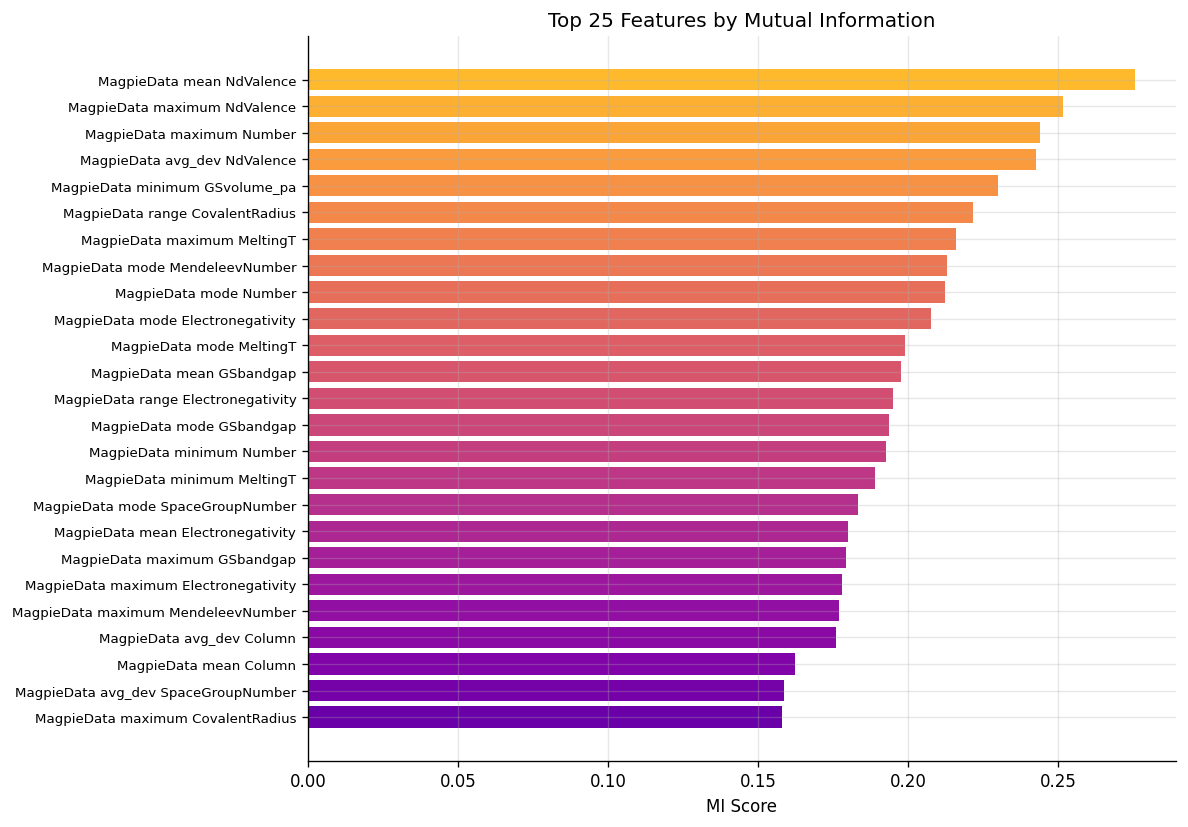

In [ ]:
# CHANGE K_MI here if you want to override the auto-selected value
K_MI = 60

top_k_feat      = mi_df.head(K_MI)['feature'].tolist()
mask_mi         = np.array([f in top_k_feat for f in feature_cols_corr])
feature_cols_mi = [feature_cols_corr[i] for i, m in enumerate(mask_mi) if m]
mi_scores_mi    = mi_scores[mask_mi]

X_train_mi = X_train_c[:, mask_mi]
X_val_mi   = X_val_c[:, mask_mi]
X_test_mi  = X_test_c[:, mask_mi]

r_mae, x_mae = quick_eval(X_train_mi, y_train, X_val_mi, y_val, f'After MI top-{K_MI}')
selection_log.append({'stage': f'MI top-{K_MI}', 'n_features': K_MI, 'ridge_mae': r_mae, 'xgb_mae': x_mae})

# Plot top 25 MI features
top25 = mi_df.head(25)
fig, ax = plt.subplots(figsize=(10, 7))
colors_mi = plt.cm.plasma(np.linspace(0.2, 0.85, 25))
ax.barh(range(25), top25['mi_score'].values[::-1], color=colors_mi)
ax.set_yticks(range(25)); ax.set_yticklabels(top25['feature'].values[::-1], fontsize=8)
ax.set_xlabel('MI Score'); ax.set_title(f'Top 25 Features by Mutual Information')
plt.tight_layout(); plt.show()

### 4D — Lasso Selection (test alpha values)

In [ ]:
print('Testing Lasso alpha for final feature selection:')
print('Higher alpha = more features zeroed = sparser model')
lasso_alpha_results = {}
for alpha in [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]:
    lsel = Lasso(alpha=alpha, max_iter=5000, random_state=42)
    lsel.fit(X_train_mi, y_train)
    mask_l = np.abs(lsel.coef_) > 0
    n_kept = mask_l.sum()
    if n_kept > 0:
        xgb_tmp = XGBRegressor(n_estimators=100, tree_method='hist', random_state=42, verbosity=0)
        xgb_tmp.fit(X_train_mi[:, mask_l], y_train)
        x_m = mean_absolute_error(y_val, xgb_tmp.predict(X_val_mi[:, mask_l]))
    else:
        x_m = 999
    print(f'  alpha={alpha:.4f} | kept={n_kept:3d} | XGB Val MAE={x_m:.4f}')
    lasso_alpha_results[alpha] = {'n_kept': n_kept, 'xgb': x_m}

LASSO_ALPHA = 0.005  # CHANGE based on results above
print(f'\nUsing Lasso alpha = {LASSO_ALPHA}')

Testing Lasso alpha for final feature selection:
Higher alpha = more features zeroed = sparser model
  alpha=0.0001 | kept= 60 | XGB Val MAE=0.4550
  alpha=0.0005 | kept= 58 | XGB Val MAE=0.4575
  alpha=0.0010 | kept= 54 | XGB Val MAE=0.4563
  alpha=0.0050 | kept= 46 | XGB Val MAE=0.4538
  alpha=0.0100 | kept= 36 | XGB Val MAE=0.4648
  alpha=0.0500 | kept= 21 | XGB Val MAE=0.5051
  alpha=0.1000 | kept= 14 | XGB Val MAE=0.5339

Using Lasso alpha = 0.005


In [ ]:
LASSO_ALPHA = 0.005
lasso_sel = Lasso(alpha=LASSO_ALPHA, max_iter=5000, random_state=42)
lasso_sel.fit(X_train_mi, y_train)
mask_lasso         = np.abs(lasso_sel.coef_) > 0
feature_cols_final = [feature_cols_mi[i] for i, m in enumerate(mask_lasso) if m]
mi_scores_final    = mi_scores_mi[mask_lasso]

X_train_sel = X_train_mi[:, mask_lasso]
X_val_sel   = X_val_mi[:, mask_lasso]
X_test_sel  = X_test_mi[:, mask_lasso]

print(f'Before Lasso: {X_train_mi.shape[1]} | After: {X_train_sel.shape[1]} | Removed: {(~mask_lasso).sum()}')
r_mae, x_mae = quick_eval(X_train_sel, y_train, X_val_sel, y_val, f'After Lasso alpha={LASSO_ALPHA}')
selection_log.append({'stage': 'Lasso', 'n_features': X_train_sel.shape[1], 'ridge_mae': r_mae, 'xgb_mae': x_mae})

print(f'\nFinal {len(feature_cols_final)} selected features:')
for i, f in enumerate(feature_cols_final, 1):
    print(f'  {i:2d}. {f}')

Before Lasso: 60 | After: 46 | Removed: 14
After Lasso alpha=0.005                | n=  46 | Ridge=0.8681 | XGB=0.5569

Final 46 selected features:
   1. MagpieData minimum Number
   2. MagpieData avg_dev Number
   3. MagpieData minimum MendeleevNumber
   4. MagpieData maximum MendeleevNumber
   5. MagpieData mode MendeleevNumber
   6. MagpieData maximum MeltingT
   7. MagpieData avg_dev MeltingT
   8. MagpieData mode MeltingT
   9. MagpieData minimum Column
  10. MagpieData maximum Column
  11. MagpieData avg_dev Column
  12. MagpieData mode Column
  13. MagpieData maximum CovalentRadius
  14. MagpieData avg_dev CovalentRadius
  15. MagpieData range Electronegativity
  16. MagpieData mean Electronegativity
  17. MagpieData mode Electronegativity
  18. MagpieData minimum NpValence
  19. MagpieData range NpValence
  20. MagpieData avg_dev NpValence
  21. MagpieData minimum NdValence
  22. MagpieData maximum NdValence
  23. MagpieData mean NdValence
  24. MagpieData avg_dev NdValence
  2

### 4E — Selection Pipeline Summary

Selection Pipeline — Performance at Each Step:
      stage  n_features  ridge_mae  xgb_mae
        Raw         132   0.824723 0.546267
   Variance         112   0.827212 0.547963
Correlation          64   0.862328 0.553955
  MI top-60          60   0.865544 0.555162
      Lasso          46   0.868050 0.556907


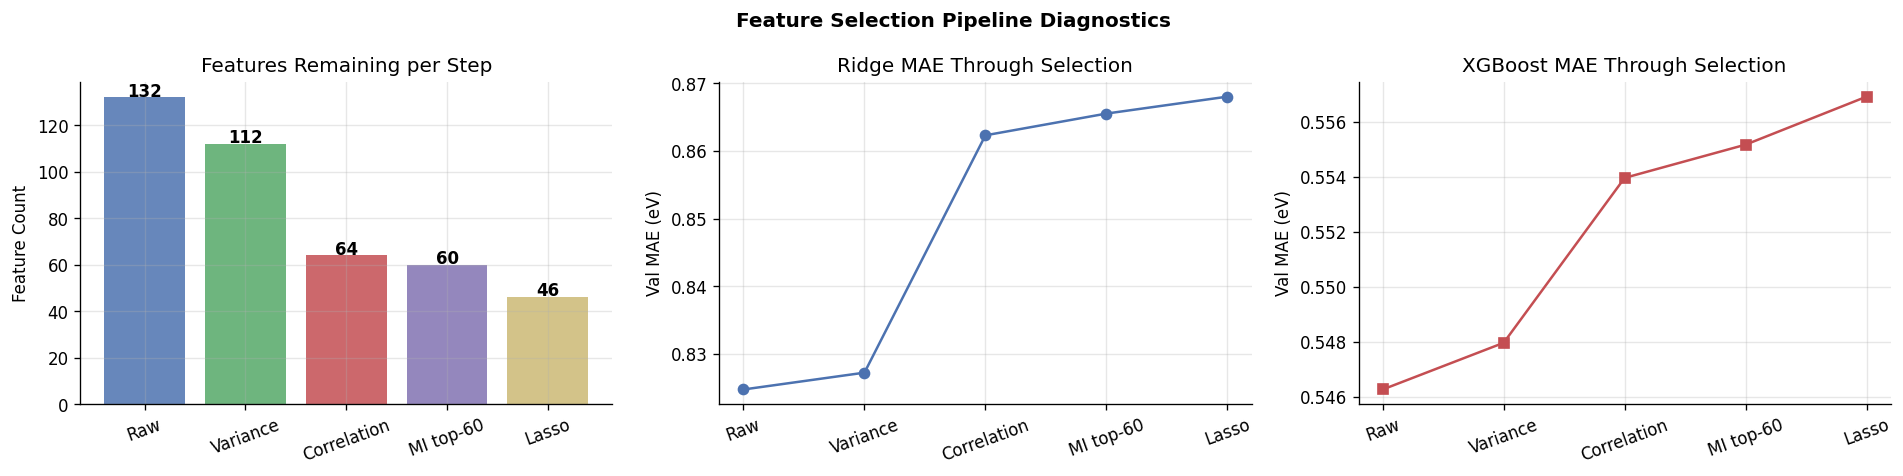

Interpretation: a step where MAE jumps means it removed useful features — revisit that threshold.


In [ ]:
sel_df = pd.DataFrame(selection_log)
print('Selection Pipeline — Performance at Each Step:')
print(sel_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(sel_df['stage'], sel_df['n_features'], color=COLORS[:len(sel_df)], alpha=0.85)
for i, (s, v) in enumerate(zip(sel_df['stage'], sel_df['n_features'])):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Feature Count'); axes[0].set_title('Features Remaining per Step')
axes[0].tick_params(axis='x', rotation=20)

axes[1].plot(sel_df['stage'], sel_df['ridge_mae'], 'o-', color=COLORS[0], label='Ridge')
axes[1].set_ylabel('Val MAE (eV)'); axes[1].set_title('Ridge MAE Through Selection')
axes[1].tick_params(axis='x', rotation=20)

axes[2].plot(sel_df['stage'], sel_df['xgb_mae'], 's-', color=COLORS[2], label='XGBoost')
axes[2].set_ylabel('Val MAE (eV)'); axes[2].set_title('XGBoost MAE Through Selection')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Feature Selection Pipeline Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/selection_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: a step where MAE jumps means it removed useful features — revisit that threshold.')

---
## 5. Feature Engineering

We use engineering strategy (polynomial)

In [ ]:
# ── Polynomial (degree 2 on top-10 MI features) ───────────────────────────────
POLY_TOP_K = 10
top_poly_idx = np.sort(np.argsort(mi_scores_final)[::-1][:POLY_TOP_K])
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sel[:, top_poly_idx])
X_val_poly   = poly.transform(X_val_sel[:, top_poly_idx])
X_test_poly  = poly.transform(X_test_sel[:, top_poly_idx])
poly_names   = list(poly.get_feature_names_out([feature_cols_final[i] for i in top_poly_idx]))
print(f'Polynomial: {POLY_TOP_K} inputs → {X_train_poly.shape[1]} features')


Polynomial: 10 inputs → 65 features


In [ ]:
# ── Assemble all feature sets ─────────────────────────────────────────────────
def stack_scale(arrays_tr, arrays_vl, arrays_te):
    Xtr = np.hstack(arrays_tr); Xvl = np.hstack(arrays_vl); Xte = np.hstack(arrays_te)
    sc  = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xvl), sc.transform(Xte)

A_tr, A_vl, A_te = X_train_sel, X_val_sel, X_test_sel  # no rescaling needed


C_tr, C_vl, C_te = stack_scale(
    [X_train_sel, X_train_poly],
    [X_val_sel,   X_val_poly],
    [X_test_sel,  X_test_poly])

feature_sets = {
    'Selected': (A_tr, A_vl, A_te, feature_cols_final),
    'full':     (C_tr, C_vl, C_te, feature_cols_final + poly_names) # + ratio_names + phys_names),
}

print('Feature set sizes:')
for name, (Xtr, *_) in feature_sets.items():
    print(f'  {name:20s}: {Xtr.shape[1]} features')

Feature set sizes:
  Selected            : 46 features
  full                : 111 features


---
## 6. Baseline Models — All Models × All Feature Sets

This is the comparison table. Each feature set isolates one type of engineering so we know what's helping.

In [ ]:
base_models = {
    'Ridge':   Ridge(alpha=1.0),
    'RF':      RandomForestRegressor(n_estimators=50,max_depth=15, n_jobs=-1, random_state=42),
    'GBM':     GradientBoostingRegressor(n_estimators=80, learning_rate=0.08, max_depth=4, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5,
                            subsample=0.8, colsample_bytree=0.8,
                            tree_method='hist', random_state=42,device='cuda', verbosity=0)
}

baseline_results = []
for fset_name, (Xtr, Xvl, Xte, _) in feature_sets.items():
    print(f'\n── {fset_name} ({Xtr.shape[1]} features) ──')
    for mname, model in base_models.items():
        m = copy.deepcopy(model)
        m.fit(Xtr, y_train)
        pred_tr = m.predict(Xtr)
        pred_vl = m.predict(Xvl)
        tr_mae = mean_absolute_error(y_train, pred_tr)
        vl_mae = mean_absolute_error(y_val,   pred_vl)
        vl_r2  = r2_score(y_val, pred_vl)
        gap    = tr_mae - vl_mae
        status = 'OVERFIT' if gap < -0.05 else ('UNDERFIT' if vl_mae > 0.6 else 'GOOD FIT')
        baseline_results.append({'Model': mname, 'Feature Set': fset_name,
                                  'Train MAE': round(tr_mae,4), 'Val MAE': round(vl_mae,4),
                                  'Val R2': round(vl_r2,4), 'Gap': round(gap,4), 'Status': status})
        print(f'  {mname:10s} | Train={tr_mae:.4f} | Val={vl_mae:.4f} | R²={vl_r2:.4f} | Gap={gap:+.4f} | {status}')

baseline_df = pd.DataFrame(baseline_results)
print('\nBaseline complete.')


── Selected (46 features) ──
  Ridge      | Train=0.8623 | Val=0.8681 | R²=0.4218 | Gap=-0.0058 | UNDERFIT
  RF         | Train=0.3247 | Val=0.4519 | R²=0.7945 | Gap=-0.1273 | OVERFIT
  GBM        | Train=0.6181 | Val=0.6350 | R²=0.6579 | Gap=-0.0169 | UNDERFIT
  XGBoost    | Train=0.5889 | Val=0.6092 | R²=0.6816 | Gap=-0.0203 | UNDERFIT

── full (111 features) ──
  Ridge      | Train=0.7873 | Val=0.7958 | R²=0.4951 | Gap=-0.0085 | UNDERFIT
  RF         | Train=0.3471 | Val=0.4657 | R²=0.7862 | Gap=-0.1186 | OVERFIT
  GBM        | Train=0.6115 | Val=0.6296 | R²=0.6632 | Gap=-0.0181 | UNDERFIT
  XGBoost    | Train=0.5776 | Val=0.5983 | R²=0.6908 | Gap=-0.0207 | GOOD FIT

Baseline complete.


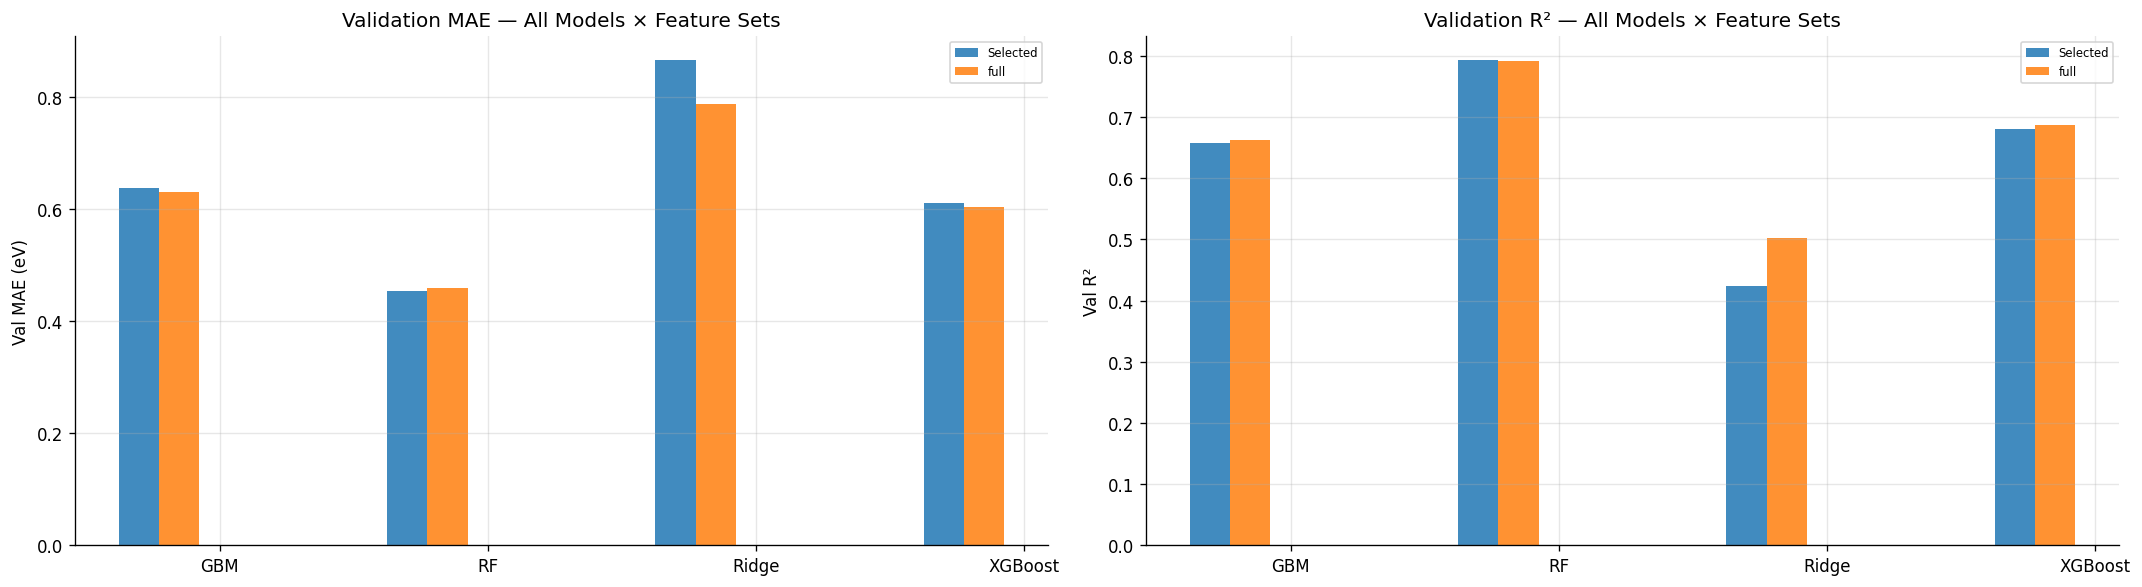


Best baseline per model (lowest Val MAE):
  Model Feature Set  Val MAE  Val R2   Status
    GBM        full   0.6305  0.6627 UNDERFIT
     RF    Selected   0.4544  0.7929  OVERFIT
  Ridge        full   0.7876  0.5027 UNDERFIT
XGBoost        full   0.6039  0.6863 UNDERFIT


In [ ]:
pivot_vl = baseline_df.pivot(index='Model', columns='Feature Set', values='Val MAE')
pivot_r2 = baseline_df.pivot(index='Model', columns='Feature Set', values='Val R2')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
x = np.arange(len(pivot_vl.index)); width = 0.15
for i, fset in enumerate(pivot_vl.columns):
    axes[0].bar(x + i*width, pivot_vl[fset], width, label=fset, alpha=0.85)
    axes[1].bar(x + i*width, pivot_r2[fset],  width, label=fset, alpha=0.85)
for ax, ylabel, title in [
    (axes[0], 'Val MAE (eV)', 'Validation MAE — All Models × Feature Sets'),
    (axes[1], 'Val R²',       'Validation R² — All Models × Feature Sets')]:
    ax.set_xticks(x + width*2); ax.set_xticklabels(pivot_vl.index)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBest baseline per model (lowest Val MAE):')
print(baseline_df.loc[baseline_df.groupby('Model')['Val MAE'].idxmin()]
      [['Model','Feature Set','Val MAE','Val R2','Status']].to_string(index=False))

---
## 7. Learning Curve Analysis

Answers: **are we data-limited, or is the model already saturated?**

- CV curve still dropping at 100% → more data would help
- CV curve flat after 50-60% → adding data won't help, improve features/model
- Large gap between train and CV → overfitting

Computing LC for Ridge...
Computing LC for RF...
Computing LC for XGBoost...


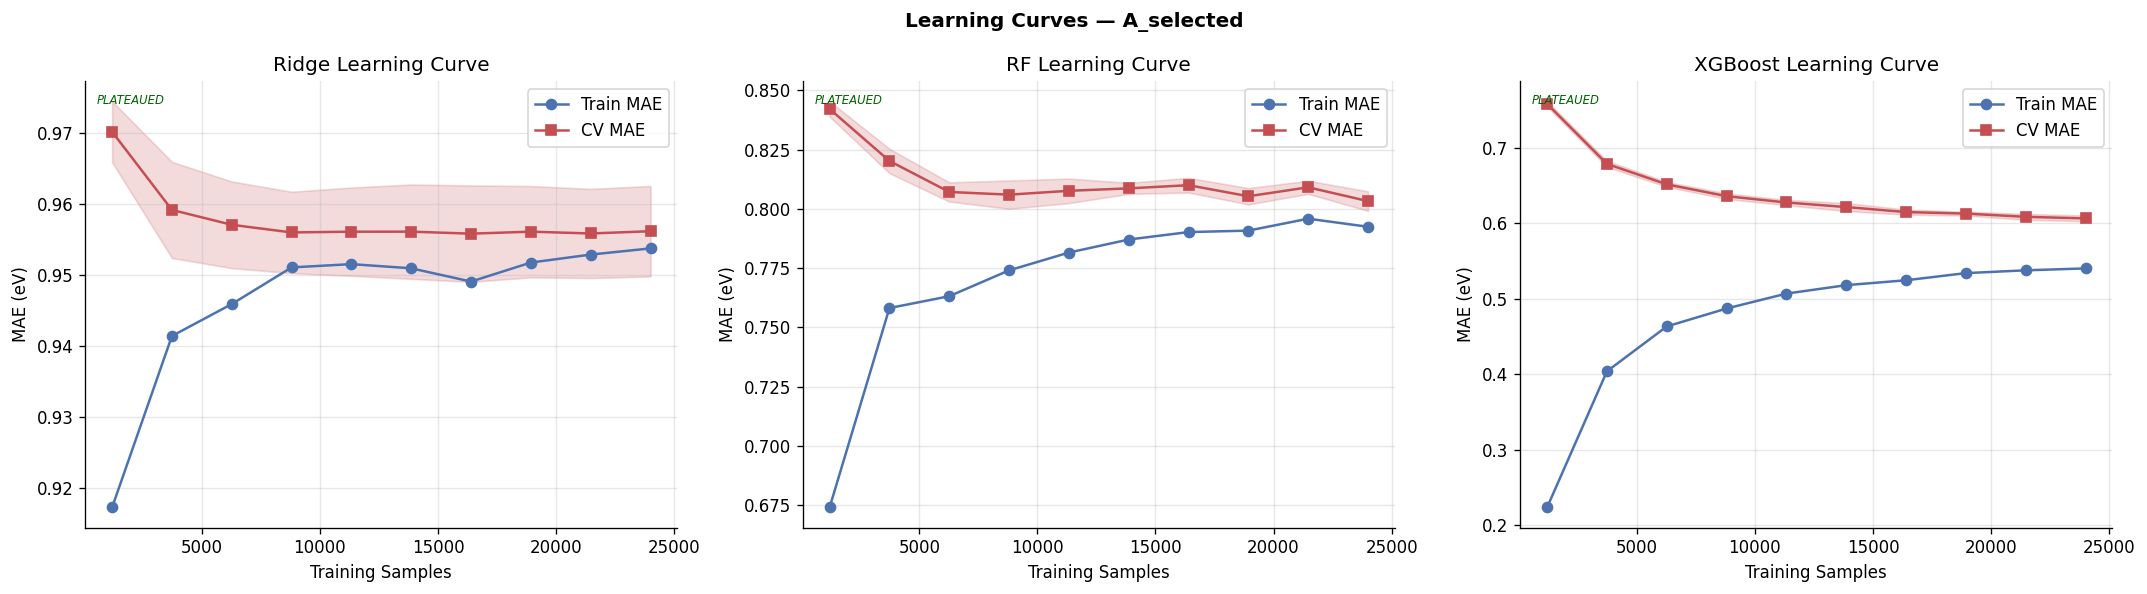

In [ ]:
# Use best feature set from baseline above — change if needed
LC_FEATURE_SET = 'Selected'
Xtr_lc, Xvl_lc, Xte_lc, _ = feature_sets[LC_FEATURE_SET]
X_lc = np.vstack([Xtr_lc, Xvl_lc])
y_lc = np.concatenate([y_train, y_val])

lc_models = {
    'Ridge':   Ridge(alpha=1.0),
    'RF':      RandomForestRegressor(n_estimators=50,max_depth=6, n_jobs=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                            tree_method='hist', random_state=42,device='cuda', verbosity=0)
}

train_sizes = np.linspace(0.05, 1.0, 10)
fig, axes   = plt.subplots(1, 3, figsize=(18, 5))
lc_results  = {}

for ax, (mname, model) in zip(axes, lc_models.items()):
    print(f'Computing LC for {mname}...')
    ts, tr_scores, cv_scores = learning_curve(
        model, X_lc, y_lc, train_sizes=train_sizes,
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
    tr_mae = -tr_scores.mean(axis=1)
    cv_mae = -cv_scores.mean(axis=1)
    cv_std =  cv_scores.std(axis=1)

    ax.plot(ts, tr_mae, 'o-', color=COLORS[0], label='Train MAE')
    ax.plot(ts, cv_mae, 's-', color=COLORS[2], label='CV MAE')
    ax.fill_between(ts, cv_mae - cv_std, cv_mae + cv_std, alpha=0.2, color=COLORS[2])
    ax.set_xlabel('Training Samples'); ax.set_ylabel('MAE (eV)')
    ax.set_title(f'{mname} Learning Curve'); ax.legend()

    # Auto diagnosis
    plateau = cv_mae[-1] >= cv_mae[int(len(ts)*0.6)] * 0.97
    overfit = (tr_mae[-1] < cv_mae[-1] * 0.8)
    diag = 'PLATEAUED' if plateau else 'STILL IMPROVING — more data would help'
    if overfit: diag += ' | OVERFIT'
    ax.text(0.02, 0.97, diag, transform=ax.transAxes, fontsize=7, va='top', color='darkgreen', style='italic')
    lc_results[mname] = {'ts': ts, 'tr_mae': tr_mae, 'cv_mae': cv_mae}

plt.suptitle(f'Learning Curves — {LC_FEATURE_SET}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Ridge — Hyperparameter Tuning Session

**Parameter:** `alpha` — regularization strength. Higher = more regularized = simpler model.  
**When Ridge overfits:** increase alpha. **When underfitting:** decrease alpha.

In [ ]:
RIDGE_FEATURE_SET = 'Selected'
Xtr_r, Xvl_r, Xte_r, _ = feature_sets[RIDGE_FEATURE_SET]

alphas = [0.01, 0.1, 1.0, 10, 100, 500, 1000, 5000]
ridge_results = []
for alpha in alphas:
    m = Ridge(alpha=alpha)
    m.fit(Xtr_r, y_train)
    tr_mae = mean_absolute_error(y_train, m.predict(Xtr_r))
    vl_mae = mean_absolute_error(y_val,   m.predict(Xvl_r))
    gap    = tr_mae - vl_mae
    status = 'OVERFIT' if gap < -0.03 else ('UNDERFIT' if vl_mae > 0.65 else 'OK')
    ridge_results.append({'alpha': alpha, 'train_mae': tr_mae, 'val_mae': vl_mae, 'gap': gap})
    print(f'  alpha={alpha:8.2f} | Train={tr_mae:.4f} | Val={vl_mae:.4f} | Gap={gap:+.4f} | {status}')

ridge_tune_df = pd.DataFrame(ridge_results)

# Optuna fine search
def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 0.001, 10000, log=True)
    return -cross_val_score(Ridge(alpha=alpha), Xtr_r, y_train, cv=5,
                            scoring='neg_mean_absolute_error').mean()


  alpha=    0.01 | Train=0.8623 | Val=0.8680 | Gap=-0.0058 | UNDERFIT
  alpha=    0.10 | Train=0.8623 | Val=0.8680 | Gap=-0.0058 | UNDERFIT
  alpha=    1.00 | Train=0.8623 | Val=0.8681 | Gap=-0.0058 | UNDERFIT
  alpha=   10.00 | Train=0.8623 | Val=0.8681 | Gap=-0.0058 | UNDERFIT
  alpha=  100.00 | Train=0.8623 | Val=0.8683 | Gap=-0.0060 | UNDERFIT
  alpha=  500.00 | Train=0.8632 | Val=0.8696 | Gap=-0.0064 | UNDERFIT
  alpha= 1000.00 | Train=0.8651 | Val=0.8716 | Gap=-0.0065 | UNDERFIT
  alpha= 5000.00 | Train=0.8796 | Val=0.8848 | Gap=-0.0052 | UNDERFIT


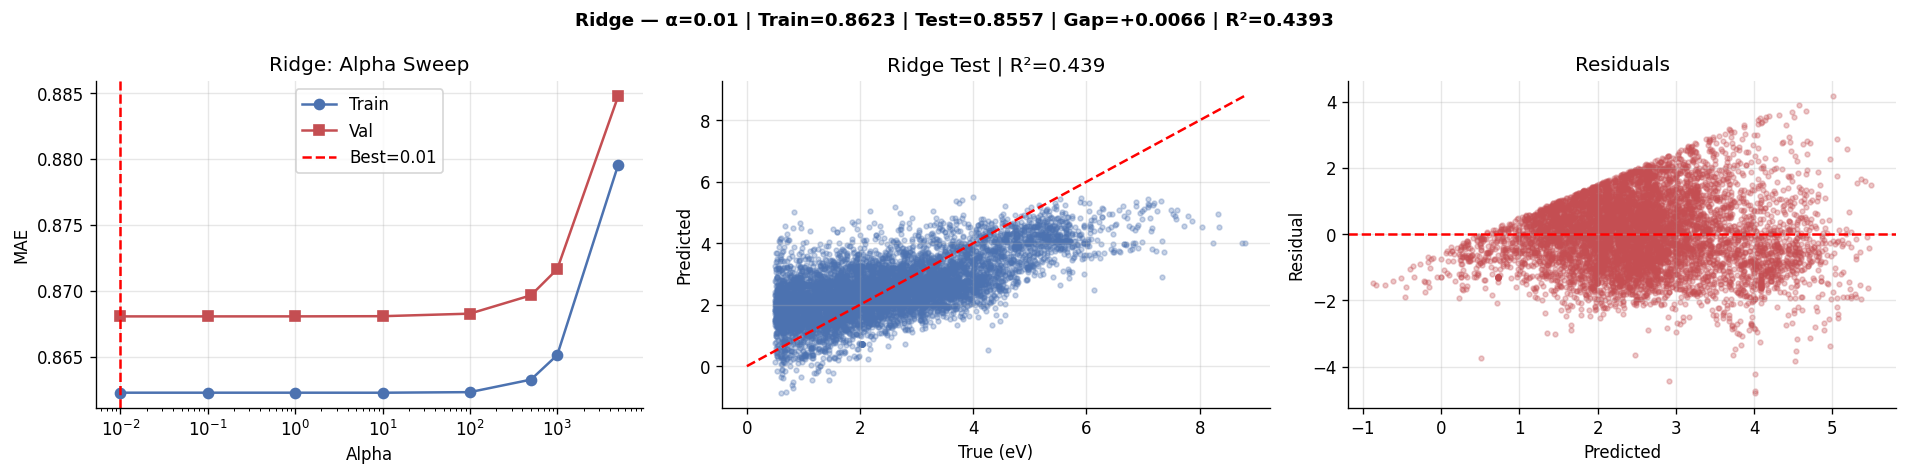

Ridge status: UNDERFIT


In [ ]:
RIDGE_BEST_ALPHA = 0.01
ridge_best = Ridge(alpha=RIDGE_BEST_ALPHA)
ridge_best.fit(Xtr_r, y_train)
ridge_train_mae = mean_absolute_error(y_train, ridge_best.predict(Xtr_r))
ridge_test_mae  = mean_absolute_error(y_test,  ridge_best.predict(Xte_r))
ridge_test_r2   = r2_score(y_test,             ridge_best.predict(Xte_r))
ridge_gap       = ridge_train_mae - ridge_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogx(ridge_tune_df['alpha'], ridge_tune_df['train_mae'], 'o-', color=COLORS[0], label='Train')
axes[0].semilogx(ridge_tune_df['alpha'], ridge_tune_df['val_mae'],   's-', color=COLORS[2], label='Val')
axes[0].axvline(RIDGE_BEST_ALPHA, color='red', linestyle='--', label=f'Best={RIDGE_BEST_ALPHA:.2f}')
axes[0].set_xlabel('Alpha'); axes[0].set_ylabel('MAE'); axes[0].set_title('Ridge: Alpha Sweep'); axes[0].legend()

pred = ridge_best.predict(Xte_r)
axes[1].scatter(y_test, pred, alpha=0.3, s=8, color=COLORS[0])
lims = [0, max(y_test.max(), pred.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True (eV)'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'Ridge Test | R²={ridge_test_r2:.3f}')

residuals = pred - y_test
axes[2].scatter(pred, residuals, alpha=0.3, s=8, color=COLORS[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual'); axes[2].set_title('Residuals')

plt.suptitle(f'Ridge — α={RIDGE_BEST_ALPHA:.2f} | Train={ridge_train_mae:.4f} | Test={ridge_test_mae:.4f} | Gap={ridge_gap:+.4f} | R²={ridge_test_r2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/ridge_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
status = 'OVERFIT' if ridge_gap < -0.03 else ('UNDERFIT' if ridge_test_mae > 0.65 else 'GOOD FIT')
print(f'Ridge status: {status}')

---
## 10. Random Forest — Hyperparameter Tuning Session

**Key tradeoffs:**
- `max_depth`: deeper = more overfit
- `min_samples_leaf`: higher = less overfit
- `max_features`: lower = more randomization = less overfit but more bias

In [ ]:
RF_FEATURE_SET = 'Selected'
Xtr_rf, Xvl_rf, Xte_rf, _ = feature_sets[RF_FEATURE_SET]

print('RF grid search — depth × min_samples_leaf:')
rf_grid_results = []
for nn in [100, 200, 300, 400]:
        m = RandomForestRegressor(n_estimators=nn, max_depth=10,
                                  min_samples_leaf=10, n_jobs=-1, random_state=42)
        m.fit(Xtr_rf, y_train)
        tr_mae = mean_absolute_error(y_train, m.predict(Xtr_rf))
        vl_mae = mean_absolute_error(y_val,   m.predict(Xvl_rf))
        gap    = tr_mae - vl_mae
        status = 'OVERFIT' if gap < -0.05 else ('UNDERFIT' if vl_mae > 0.6 else 'OK')
        print(f'  nn={str(nn):4s} | Train={tr_mae:.4f} | Val={vl_mae:.4f} | Gap={gap:+.4f} | {status}')
        rf_grid_results.append({'nn': str(nn),
                                 'train_mae': tr_mae, 'val_mae': vl_mae, 'gap': gap})
rf_grid_df = pd.DataFrame(rf_grid_results)

RF grid search — depth × min_samples_leaf:
  nn=100  | Train=0.5456 | Val=0.5829 | Gap=-0.0373 | OK
  nn=200  | Train=0.5443 | Val=0.5817 | Gap=-0.0375 | OK
  nn=300  | Train=0.5452 | Val=0.5825 | Gap=-0.0372 | OK
  nn=400  | Train=0.5448 | Val=0.5825 | Gap=-0.0376 | OK


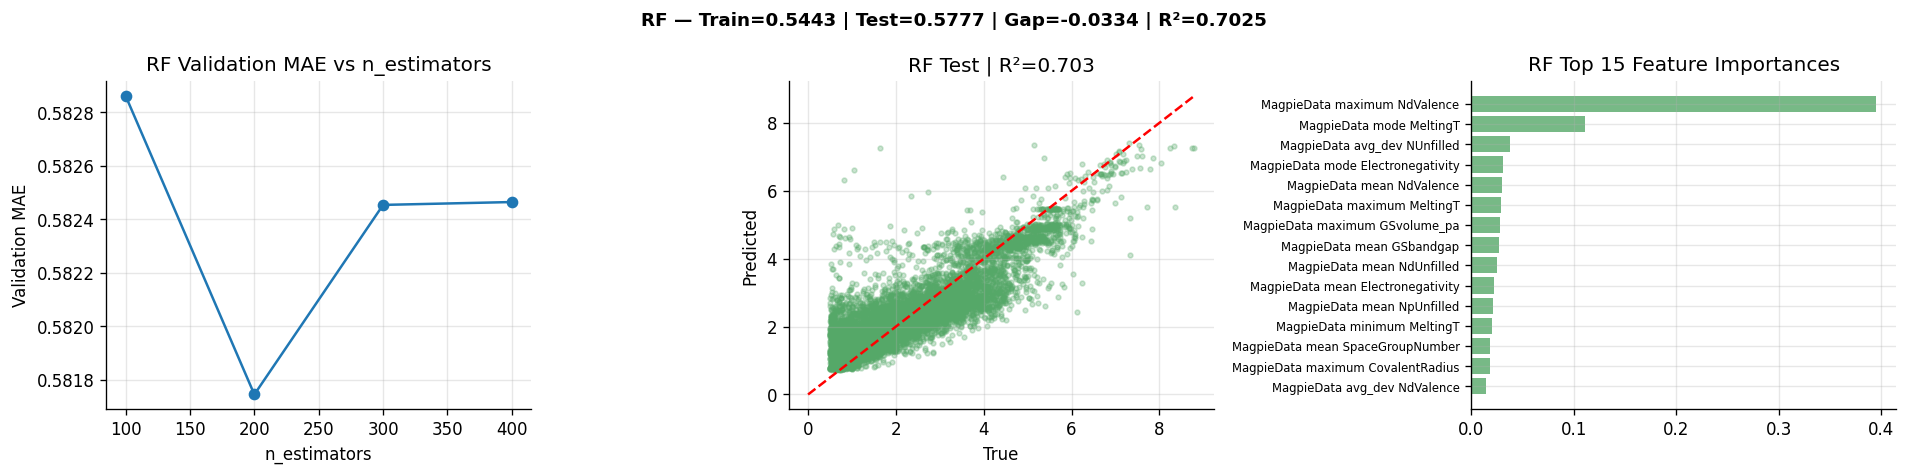

Status: GOOD FIT


In [ ]:
RF_FEATURE_SET = 'Selected'
Xtr_rf, Xvl_rf, Xte_rf, feat_rf = feature_sets[RF_FEATURE_SET]

rf_best = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

rf_best.fit(Xtr_rf, y_train)

rf_train_pred = rf_best.predict(Xtr_rf)
rf_test_pred  = rf_best.predict(Xte_rf)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae  = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2   = r2_score(y_test, rf_test_pred)
rf_gap       = rf_train_mae - rf_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Validation MAE vs n_estimators
axes[0].plot(
    rf_grid_df['nn'].astype(int),
    rf_grid_df['val_mae'],
    marker='o'
)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Validation MAE')
axes[0].set_title('RF Validation MAE vs n_estimators')
axes[0].grid(True)

# 2. True vs Predicted scatter
axes[1].scatter(y_test, rf_test_pred, alpha=0.3, s=8, color=COLORS[1])
lims = [0, max(y_test.max(), rf_test_pred.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'RF Test | R²={rf_test_r2:.3f}')

# 3. Feature importance
imp = rf_best.feature_importances_
top15 = np.argsort(imp)[::-1][:15]

axes[2].barh(range(15), imp[top15][::-1], color=COLORS[1], alpha=0.8)
axes[2].set_yticks(range(15))
axes[2].set_yticklabels([feat_rf[i] for i in top15][::-1], fontsize=7)
axes[2].set_title('RF Top 15 Feature Importances')

plt.suptitle(
    f'RF — Train={rf_train_mae:.4f} | Test={rf_test_mae:.4f} | '
    f'Gap={rf_gap:+.4f} | R²={rf_test_r2:.4f}',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/rf_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Status:',
      'OVERFIT' if rf_gap < -0.05
      else ('UNDERFIT' if rf_test_mae > 0.6 else 'GOOD FIT'))

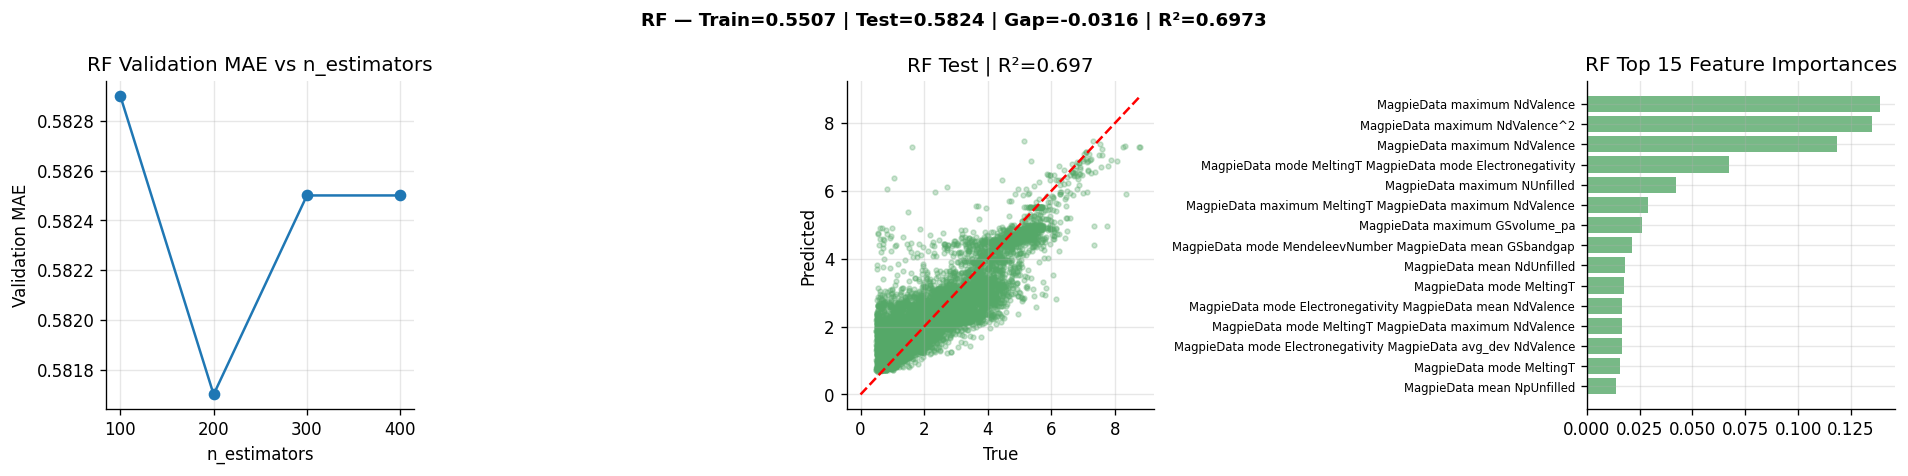

Status: GOOD FIT


In [ ]:
RF_FEATURE_SET = 'full'
Xtr_rf, Xvl_rf, Xte_rf, feat_rf = feature_sets[RF_FEATURE_SET]

rf_best = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

rf_best.fit(Xtr_rf, y_train)

rf_train_pred = rf_best.predict(Xtr_rf)
rf_test_pred  = rf_best.predict(Xte_rf)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae  = mean_absolute_error(y_test, rf_test_pred)
rf_test_r2   = r2_score(y_test, rf_test_pred)
rf_gap       = rf_train_mae - rf_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Validation MAE vs n_estimators
axes[0].plot(
    rf_grid_df['nn'].astype(int),
    rf_grid_df['val_mae'],
    marker='o'
)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Validation MAE')
axes[0].set_title('RF Validation MAE vs n_estimators')
axes[0].grid(True)

# 2. True vs Predicted scatter
axes[1].scatter(y_test, rf_test_pred, alpha=0.3, s=8, color=COLORS[1])
lims = [0, max(y_test.max(), rf_test_pred.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'RF Test | R²={rf_test_r2:.3f}')

# 3. Feature importance
imp = rf_best.feature_importances_
top15 = np.argsort(imp)[::-1][:15]

axes[2].barh(range(15), imp[top15][::-1], color=COLORS[1], alpha=0.8)
axes[2].set_yticks(range(15))
axes[2].set_yticklabels([feat_rf[i] for i in top15][::-1], fontsize=7)
axes[2].set_title('RF Top 15 Feature Importances')

plt.suptitle(
    f'RF — Train={rf_train_mae:.4f} | Test={rf_test_mae:.4f} | '
    f'Gap={rf_gap:+.4f} | R²={rf_test_r2:.4f}',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/rf_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Status:',
      'OVERFIT' if rf_gap < -0.05
      else ('UNDERFIT' if rf_test_mae > 0.6 else 'GOOD FIT'))

---
## 11. Gradient Boosting — Hyperparameter Tuning Session

**Key tradeoff:** low `learning_rate` + more `n_estimators` usually beats high lr + fewer trees.  
The staged prediction plot shows exactly where the model starts overfitting.

In [ ]:
GBM_FEATURE_SET = 'Selected'
Xtr_g, Xvl_g, Xte_g, _ = feature_sets[GBM_FEATURE_SET]

print('GBM: learning rate × n_estimators tradeoff:')
gbm_lr_results = []
for depth in [5, 10, 20, 30]:
    for n_est in [100, 200, 300]:
        m = GradientBoostingRegressor(n_estimators=n_est, learning_rate=0.2, max_depth=depth, random_state=42)
        m.fit(Xtr_g, y_train)
        tr_mae = mean_absolute_error(y_train, m.predict(Xtr_g))
        vl_mae = mean_absolute_error(y_val,   m.predict(Xvl_g))
        print(f'  depth={depth:.2f} n={n_est:3d} | Train={tr_mae:.4f} | Val={vl_mae:.4f} | Gap={tr_mae-vl_mae:+.4f}')
        gbm_lr_results.append({'depth': depth, 'n_est': n_est, 'train_mae': tr_mae, 'val_mae': vl_mae})
gbm_lr_df = pd.DataFrame(gbm_lr_results)

GBM: learning rate × n_estimators tradeoff:
  depth=5.00 n=100 | Train=0.4665 | Val=0.5161 | Gap=-0.0496
  depth=5.00 n=200 | Train=0.3951 | Val=0.4729 | Gap=-0.0778
  depth=5.00 n=300 | Train=0.3517 | Val=0.4533 | Gap=-0.1016
  depth=10.00 n=100 | Train=0.1845 | Val=0.4002 | Gap=-0.2157
  depth=10.00 n=200 | Train=0.1299 | Val=0.3898 | Gap=-0.2599
  depth=10.00 n=300 | Train=0.1040 | Val=0.3867 | Gap=-0.2827
  depth=20.00 n=100 | Train=0.0700 | Val=0.4101 | Gap=-0.3402
  depth=20.00 n=200 | Train=0.0699 | Val=0.4101 | Gap=-0.3402
  depth=20.00 n=300 | Train=0.0699 | Val=0.4101 | Gap=-0.3402
  depth=30.00 n=100 | Train=0.0699 | Val=0.4621 | Gap=-0.3922
  depth=30.00 n=200 | Train=0.0699 | Val=0.4621 | Gap=-0.3922


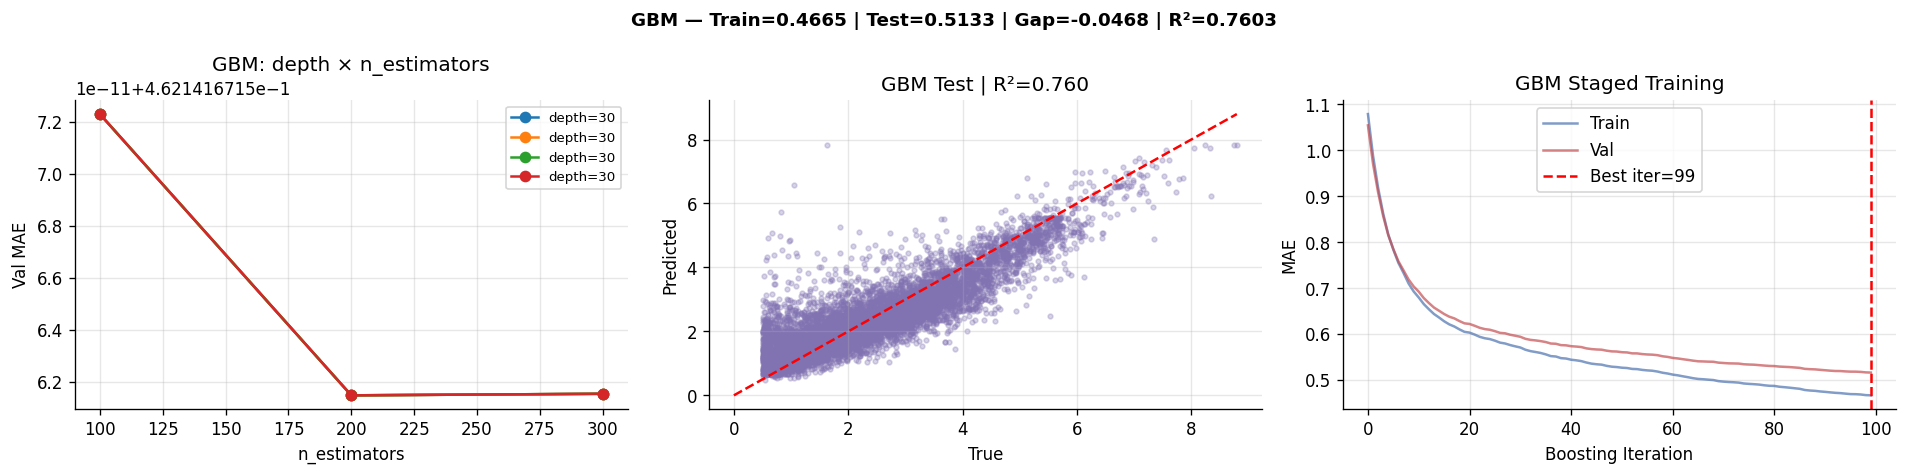

Status: GOOD FIT


In [ ]:
GBM_FEATURE_SET = 'Selected'
Xtr_g, Xvl_g, Xte_g, _ = feature_sets[GBM_FEATURE_SET]

GBM_BEST = {
    'n_estimators': 100,
    'learning_rate': 0.02,
    'max_depth': 5,
    'subsample': 0.8
}

gbm_best = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=5, random_state=42)
gbm_best.fit(Xtr_g, y_train)
gbm_train_mae = mean_absolute_error(y_train, gbm_best.predict(Xtr_g))
gbm_test_mae  = mean_absolute_error(y_test,  gbm_best.predict(Xte_g))
gbm_test_r2   = r2_score(y_test,             gbm_best.predict(Xte_g))
gbm_gap       = gbm_train_mae - gbm_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for depth in gbm_lr_df['depth'].unique():
    sub = gbm_lr_df[gbm_lr_df['depth'] == depth]
    axes[0].plot(sub['n_est'], sub['val_mae'], 'o-', label=f'depth={depth}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Val MAE')
axes[0].set_title('GBM: depth × n_estimators'); axes[0].legend(fontsize=8)

pred_g = gbm_best.predict(Xte_g)
axes[1].scatter(y_test, pred_g, alpha=0.3, s=8, color=COLORS[3])
lims = [0, max(y_test.max(), pred_g.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'GBM Test | R²={gbm_test_r2:.3f}')

staged_tr = np.array([mean_absolute_error(y_train, yp) for yp in gbm_best.staged_predict(Xtr_g)])
staged_vl = np.array([mean_absolute_error(y_val,   yp) for yp in gbm_best.staged_predict(Xvl_g)])
axes[2].plot(staged_tr, color=COLORS[0], label='Train', alpha=0.7)
axes[2].plot(staged_vl, color=COLORS[2], label='Val',   alpha=0.7)
best_iter = np.argmin(staged_vl)
axes[2].axvline(best_iter, color='red', linestyle='--', label=f'Best iter={best_iter}')
axes[2].set_xlabel('Boosting Iteration'); axes[2].set_ylabel('MAE')
axes[2].set_title('GBM Staged Training'); axes[2].legend()

plt.suptitle(f'GBM — Train={gbm_train_mae:.4f} | Test={gbm_test_mae:.4f} | Gap={gbm_gap:+.4f} | R²={gbm_test_r2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/gbm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Status:', 'OVERFIT' if gbm_gap < -0.05 else ('UNDERFIT' if gbm_test_mae > 0.6 else 'GOOD FIT'))

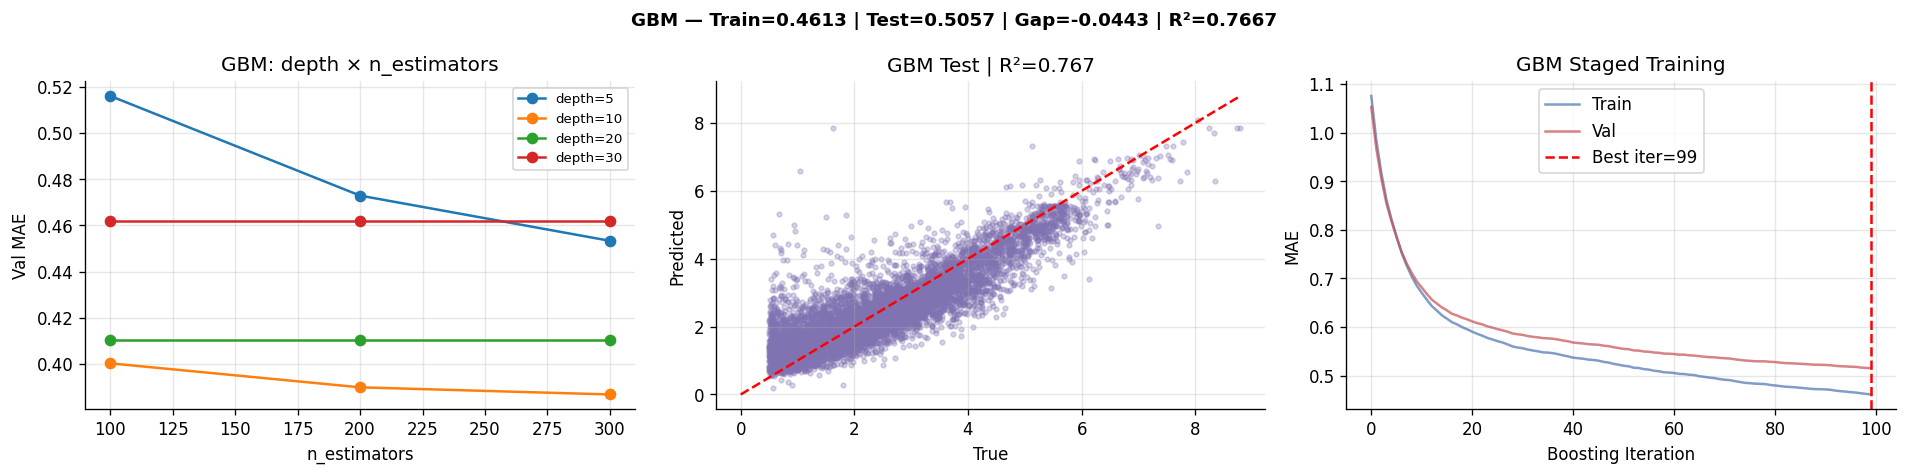

Status: GOOD FIT


In [ ]:
GBM_FEATURE_SET = 'full'
Xtr_g, Xvl_g, Xte_g, _ = feature_sets[GBM_FEATURE_SET]

GBM_BEST = {
    'n_estimators': 100,
    'learning_rate': 0.02,
    'max_depth': 5,
    'subsample': 0.8
}

gbm_best = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=5, random_state=42)
gbm_best.fit(Xtr_g, y_train)
gbm_train_mae = mean_absolute_error(y_train, gbm_best.predict(Xtr_g))
gbm_test_mae  = mean_absolute_error(y_test,  gbm_best.predict(Xte_g))
gbm_test_r2   = r2_score(y_test,             gbm_best.predict(Xte_g))
gbm_gap       = gbm_train_mae - gbm_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for depth in gbm_lr_df['depth'].unique():
    sub = gbm_lr_df[gbm_lr_df['depth'] == depth]
    axes[0].plot(sub['n_est'], sub['val_mae'], 'o-', label=f'depth={depth}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Val MAE')
axes[0].set_title('GBM: depth × n_estimators'); axes[0].legend(fontsize=8)

pred_g = gbm_best.predict(Xte_g)
axes[1].scatter(y_test, pred_g, alpha=0.3, s=8, color=COLORS[3])
lims = [0, max(y_test.max(), pred_g.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'GBM Test | R²={gbm_test_r2:.3f}')

staged_tr = np.array([mean_absolute_error(y_train, yp) for yp in gbm_best.staged_predict(Xtr_g)])
staged_vl = np.array([mean_absolute_error(y_val,   yp) for yp in gbm_best.staged_predict(Xvl_g)])
axes[2].plot(staged_tr, color=COLORS[0], label='Train', alpha=0.7)
axes[2].plot(staged_vl, color=COLORS[2], label='Val',   alpha=0.7)
best_iter = np.argmin(staged_vl)
axes[2].axvline(best_iter, color='red', linestyle='--', label=f'Best iter={best_iter}')
axes[2].set_xlabel('Boosting Iteration'); axes[2].set_ylabel('MAE')
axes[2].set_title('GBM Staged Training'); axes[2].legend()

plt.suptitle(f'GBM — Train={gbm_train_mae:.4f} | Test={gbm_test_mae:.4f} | Gap={gbm_gap:+.4f} | R²={gbm_test_r2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/gbm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Status:', 'OVERFIT' if gbm_gap < -0.05 else ('UNDERFIT' if gbm_test_mae > 0.6 else 'GOOD FIT'))

---
## 12. XGBoost — Hyperparameter Tuning Session

**Most parameters, most impact.**  
- `subsample` + `colsample_bytree`: stochastic regularization (reduce overfit)
- `min_child_weight`: prevents splits on small node groups
- `reg_alpha` (L1) + `reg_lambda` (L2): explicit weight regularization
- Lower `learning_rate` + more `n_estimators` = better generalization (use early stopping)

In [ ]:
XGB_FEATURE_SET = 'full'  # use best feature set from baseline
Xtr_x, Xvl_x, Xte_x, _ = feature_sets[XGB_FEATURE_SET]

print('XGBoost: depth × subsample grid:')
xgb_grid_results = []
for depth in [4, 5, 6, 8]:
    for ss in [0.6, 0.8, 1.0]:
        m = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=depth,
                         subsample=ss, colsample_bytree=0.8,
                         tree_method='hist',device='cuda', random_state=42, verbosity=0)
        m.fit(Xtr_x, y_train, eval_set=[(Xvl_x, y_val)], verbose=False)
        tr_mae = mean_absolute_error(y_train, m.predict(Xtr_x))
        vl_mae = mean_absolute_error(y_val,   m.predict(Xvl_x))
        print(f'  depth={depth} ss={ss} | Train={tr_mae:.4f} | Val={vl_mae:.4f} | Gap={tr_mae-vl_mae:+.4f}')
        xgb_grid_results.append({'depth': depth, 'subsample': ss, 'train_mae': tr_mae, 'val_mae': vl_mae})
xgb_grid_df = pd.DataFrame(xgb_grid_results)

XGBoost: depth × subsample grid:
  depth=4 ss=0.6 | Train=0.5764 | Val=0.5976 | Gap=-0.0213
  depth=4 ss=0.8 | Train=0.5769 | Val=0.5972 | Gap=-0.0203
  depth=4 ss=1.0 | Train=0.5769 | Val=0.5977 | Gap=-0.0208
  depth=5 ss=0.6 | Train=0.5187 | Val=0.5501 | Gap=-0.0314
  depth=5 ss=0.8 | Train=0.5176 | Val=0.5504 | Gap=-0.0328
  depth=5 ss=1.0 | Train=0.5194 | Val=0.5507 | Gap=-0.0313
  depth=6 ss=0.6 | Train=0.4623 | Val=0.5112 | Gap=-0.0490
  depth=6 ss=0.8 | Train=0.4585 | Val=0.5067 | Gap=-0.0482
  depth=6 ss=1.0 | Train=0.4574 | Val=0.5082 | Gap=-0.0508
  depth=8 ss=0.6 | Train=0.3571 | Val=0.4520 | Gap=-0.0949
  depth=8 ss=0.8 | Train=0.3477 | Val=0.4436 | Gap=-0.0959
  depth=8 ss=1.0 | Train=0.3381 | Val=0.4415 | Gap=-0.1034


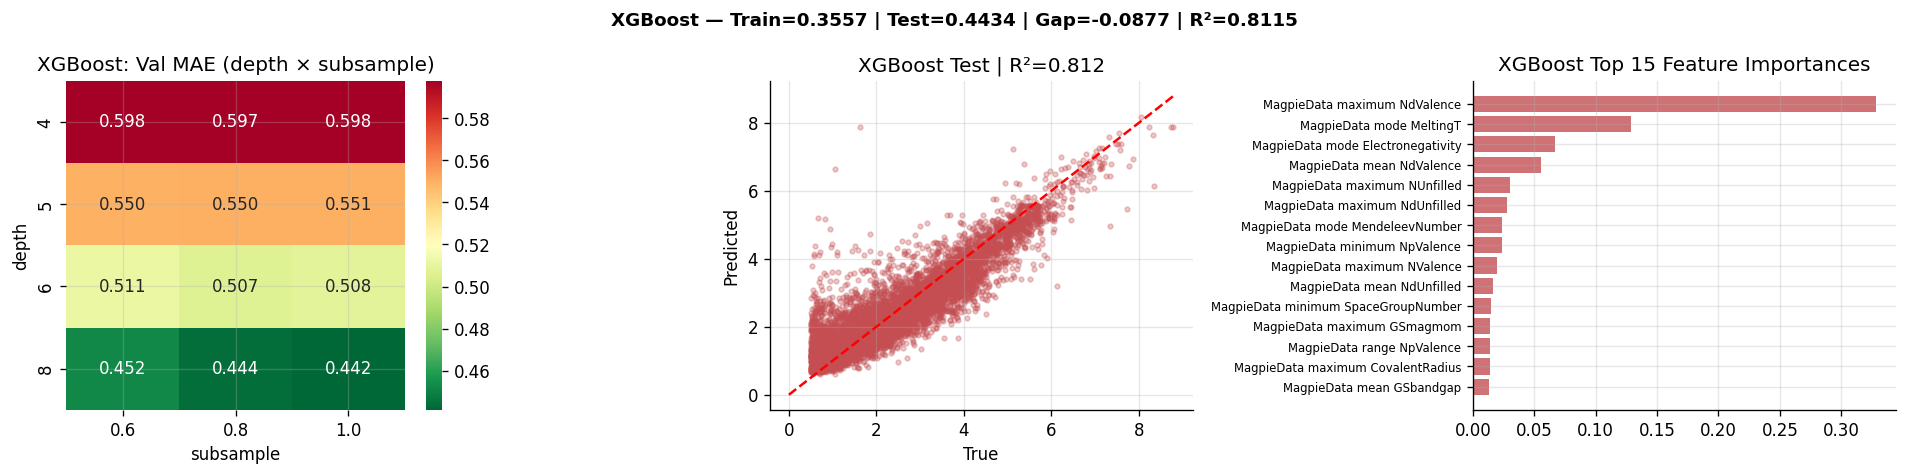

Status: GOOD FIT


In [ ]:
XGB_FEATURE_SET = 'Selected'  # use best feature set from baseline
Xtr_x, Xvl_x, Xte_x, _ = feature_sets[XGB_FEATURE_SET]

XGB_BEST = {
    'n_estimators': 200,
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 1.0,
    'colsample_bytree': 0.8
}
xgb_best = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=8,
                         subsample=1.0, colsample_bytree=0.8,
                         tree_method='hist',device='cuda', random_state=42, verbosity=0)
xgb_best.fit(Xtr_x, y_train)
xgb_train_mae = mean_absolute_error(y_train, xgb_best.predict(Xtr_x))
xgb_test_mae  = mean_absolute_error(y_test,  xgb_best.predict(Xte_x))
xgb_test_r2   = r2_score(y_test,             xgb_best.predict(Xte_x))
xgb_gap       = xgb_train_mae - xgb_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
piv_x = xgb_grid_df.pivot(index='depth', columns='subsample', values='val_mae')
sns.heatmap(piv_x, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('XGBoost: Val MAE (depth × subsample)')

pred_x = xgb_best.predict(Xte_x)
axes[1].scatter(y_test, pred_x, alpha=0.3, s=8, color=COLORS[2])
lims = [0, max(y_test.max(), pred_x.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'XGBoost Test | R²={xgb_test_r2:.3f}')

_, _, _, feat_x = feature_sets[XGB_FEATURE_SET]
imp_x = xgb_best.feature_importances_
n_x   = min(len(imp_x), len(feat_x))
top15 = np.argsort(imp_x[:n_x])[::-1][:15]
axes[2].barh(range(15), imp_x[top15][::-1], color=COLORS[2], alpha=0.8)
axes[2].set_yticks(range(15)); axes[2].set_yticklabels([feat_x[i] for i in top15][::-1], fontsize=7)
axes[2].set_title('XGBoost Top 15 Feature Importances')

plt.suptitle(f'XGBoost — Train={xgb_train_mae:.4f} | Test={xgb_test_mae:.4f} | Gap={xgb_gap:+.4f} | R²={xgb_test_r2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/xgb_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Status:', 'OVERFIT' if xgb_gap < -0.1 else ('UNDERFIT' if xgb_test_mae > 0.6 else 'GOOD FIT'))

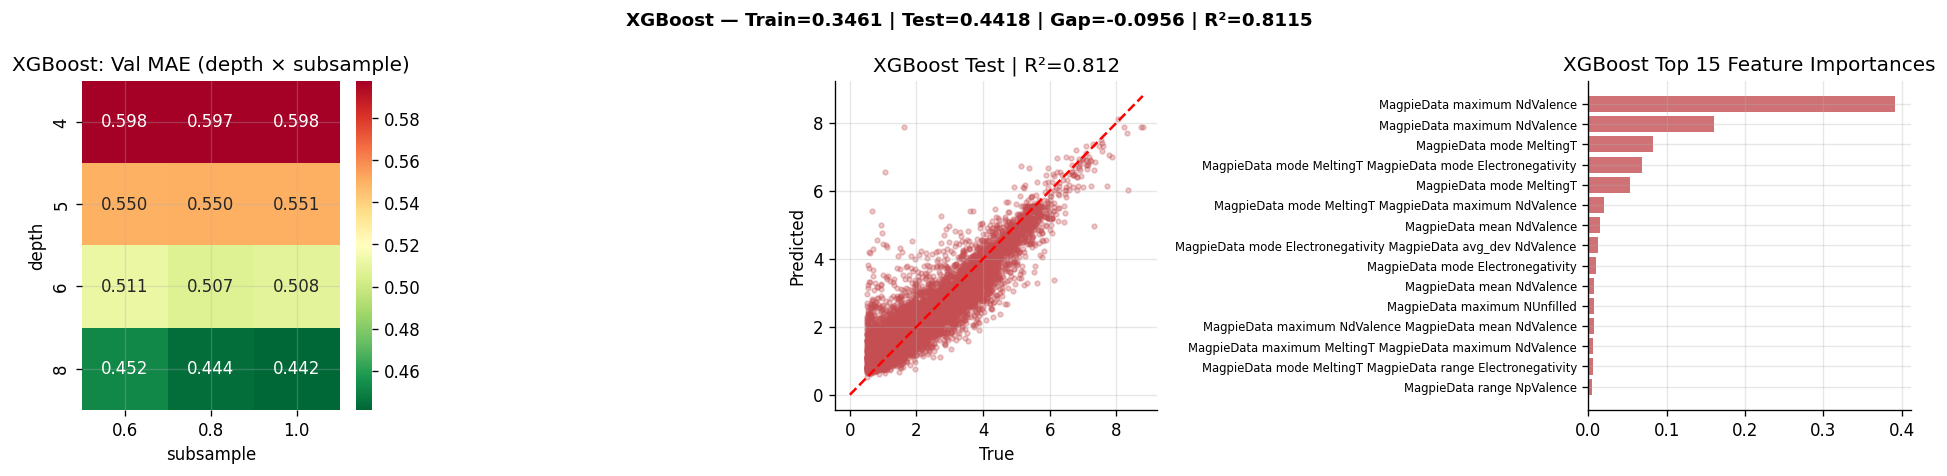

Status: GOOD FIT


In [ ]:
XGB_FEATURE_SET = 'full'  # use best feature set from baseline
Xtr_x, Xvl_x, Xte_x, _ = feature_sets[XGB_FEATURE_SET]

XGB_BEST = {
    'n_estimators': 200,
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 1.0,
    'colsample_bytree': 0.8
}
xgb_best = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=8,
                         subsample=1.0, colsample_bytree=0.8,
                         tree_method='hist',device='cuda', random_state=42, verbosity=0)
xgb_best.fit(Xtr_x, y_train)
xgb_train_mae = mean_absolute_error(y_train, xgb_best.predict(Xtr_x))
xgb_test_mae  = mean_absolute_error(y_test,  xgb_best.predict(Xte_x))
xgb_test_r2   = r2_score(y_test,             xgb_best.predict(Xte_x))
xgb_gap       = xgb_train_mae - xgb_test_mae

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
piv_x = xgb_grid_df.pivot(index='depth', columns='subsample', values='val_mae')
sns.heatmap(piv_x, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title('XGBoost: Val MAE (depth × subsample)')

pred_x = xgb_best.predict(Xte_x)
axes[1].scatter(y_test, pred_x, alpha=0.3, s=8, color=COLORS[2])
lims = [0, max(y_test.max(), pred_x.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('True'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'XGBoost Test | R²={xgb_test_r2:.3f}')

_, _, _, feat_x = feature_sets[XGB_FEATURE_SET]
imp_x = xgb_best.feature_importances_
n_x   = min(len(imp_x), len(feat_x))
top15 = np.argsort(imp_x[:n_x])[::-1][:15]
axes[2].barh(range(15), imp_x[top15][::-1], color=COLORS[2], alpha=0.8)
axes[2].set_yticks(range(15)); axes[2].set_yticklabels([feat_x[i] for i in top15][::-1], fontsize=7)
axes[2].set_title('XGBoost Top 15 Feature Importances')

plt.suptitle(f'XGBoost — Train={xgb_train_mae:.4f} | Test={xgb_test_mae:.4f} | Gap={xgb_gap:+.4f} | R²={xgb_test_r2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/xgb_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Status:', 'OVERFIT' if xgb_gap < -0.1 else ('UNDERFIT' if xgb_test_mae > 0.6 else 'GOOD FIT'))

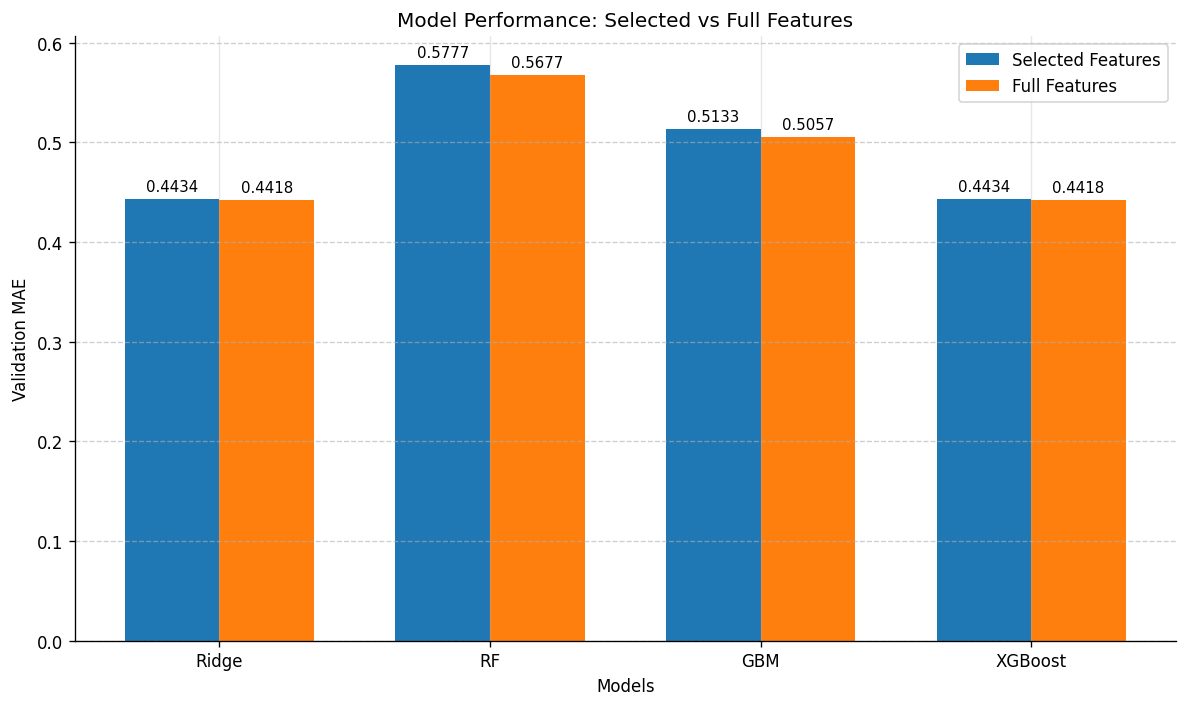

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Fill your validation scores here
# =========================
models = ['Ridge', 'RF', 'GBM', 'XGBoost']


selected_scores = [
    0.4434,   # Ridge selected
    0.5777,   # RF selected
    0.5133,   # GBM selected
    0.4434    # XGB selected
]

full_scores = [
    0.4418,   # Ridge full
    0.5677,   # RF full
    0.5057,   # GBM full
    0.4418    # XGB full
]

# =========================
# Plot
# =========================
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, selected_scores, width, label='Selected Features')
bars2 = plt.bar(x + width/2, full_scores, width, label='Full Features')

plt.xlabel('Models')
plt.ylabel('Validation MAE')
plt.title('Model Performance: Selected vs Full Features')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

---
## 13. SHAP Analysis

Run on the best model (XGBoost). SHAP answers:
- Which features actually drive predictions?
- Does the model's behavior match physical intuition?
- Where does the model fail and why?
- Do the SHAP top features align with what MI selected?

In [ ]:
SHAP_FEAT_SET = XGB_FEATURE_SET
_, _, Xte_shap, feat_shap = feature_sets[SHAP_FEAT_SET]
n_align = min(Xte_shap.shape[1], len(feat_shap))
Xte_shap    = Xte_shap[:, :n_align]
feat_shap   = feat_shap[:n_align]

np.random.seed(42)
shap_idx     = np.random.choice(len(Xte_shap), size=min(2000, len(Xte_shap)), replace=False)
Xte_shap_s   = Xte_shap[shap_idx]

print('Computing SHAP values (may take 2-3 min)...')
explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(Xte_shap_s)
print(f'Done. Shape: {shap_values.shape}')

Computing SHAP values (may take 2-3 min)...
Done. Shape: (2000, 111)


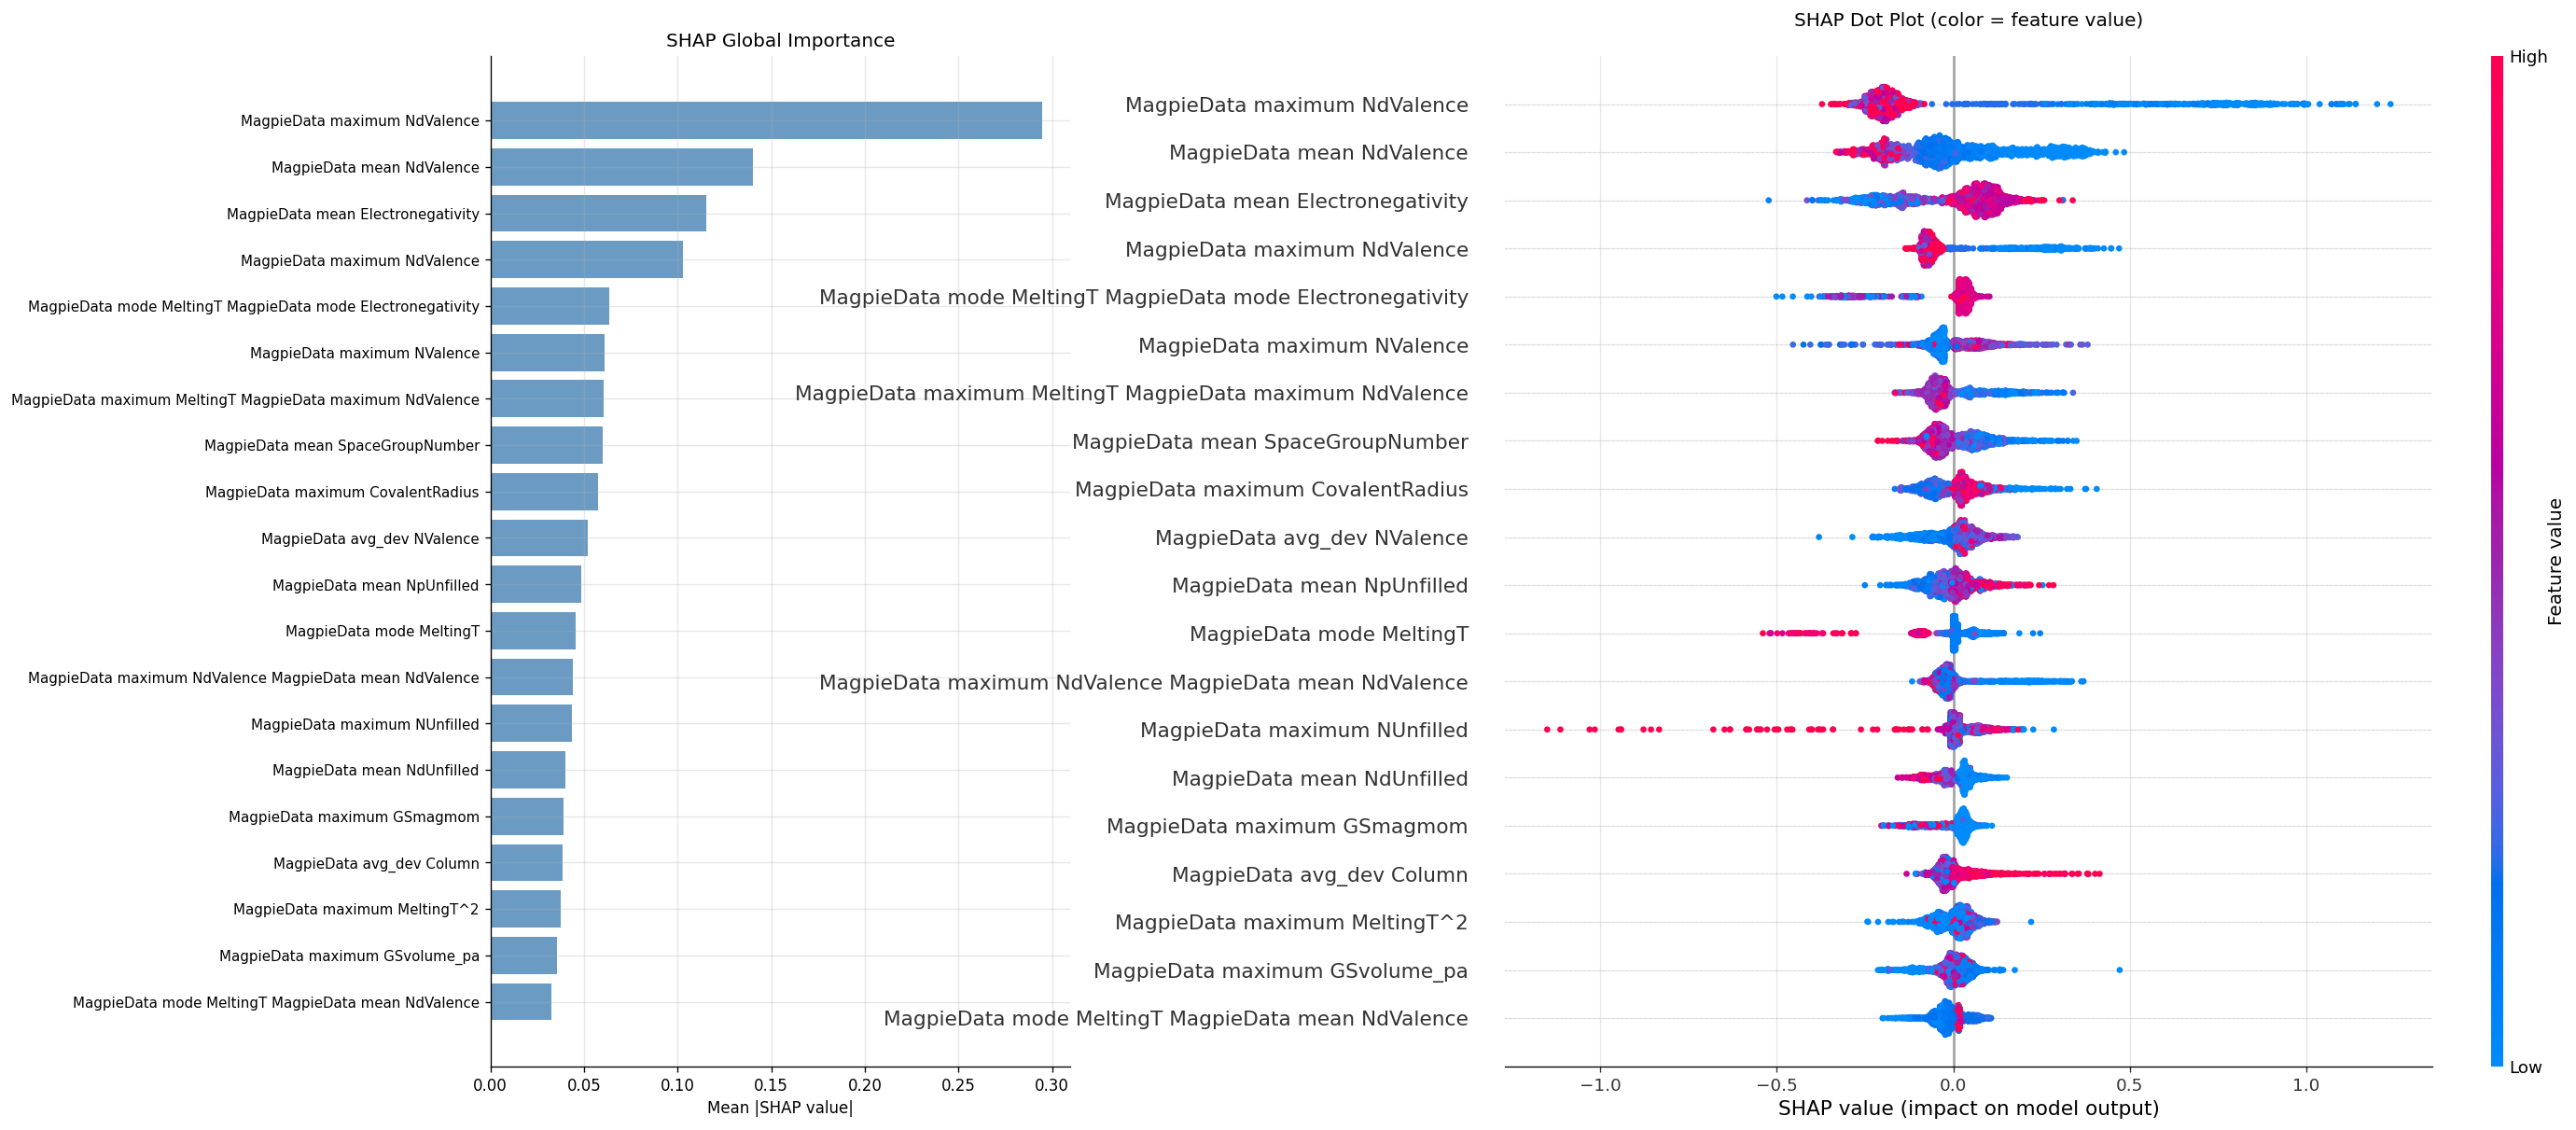

In [ ]:
# 13A — Global importance + summary dot
shap_imp = np.abs(shap_values).mean(axis=0)
top20 = np.argsort(shap_imp)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(24, 10), gridspec_kw={'width_ratios': [1, 2]})

# Left plot: bar chart
axes[0].barh(
    range(20),
    shap_imp[top20][::-1],
    color='steelblue',
    alpha=0.8
)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([feat_shap[i] for i in top20][::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('SHAP Global Importance')

# Right plot: SHAP summary dot plot
shap.summary_plot(
    shap_values,
    Xte_shap_s,
    feature_names=feat_shap,
    max_display=20,
    show=False,
    plot_size=None   # IMPORTANT: prevents SHAP from resizing figure
)

# Move SHAP plot into second subplot area
plt.sca(axes[1])
axes[1].set_title('SHAP Dot Plot (color = feature value)', pad=20)

plt.subplots_adjust(wspace=0.5)   # more spacing
plt.savefig(
    '/content/drive/MyDrive/ML Project/shap_summary.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

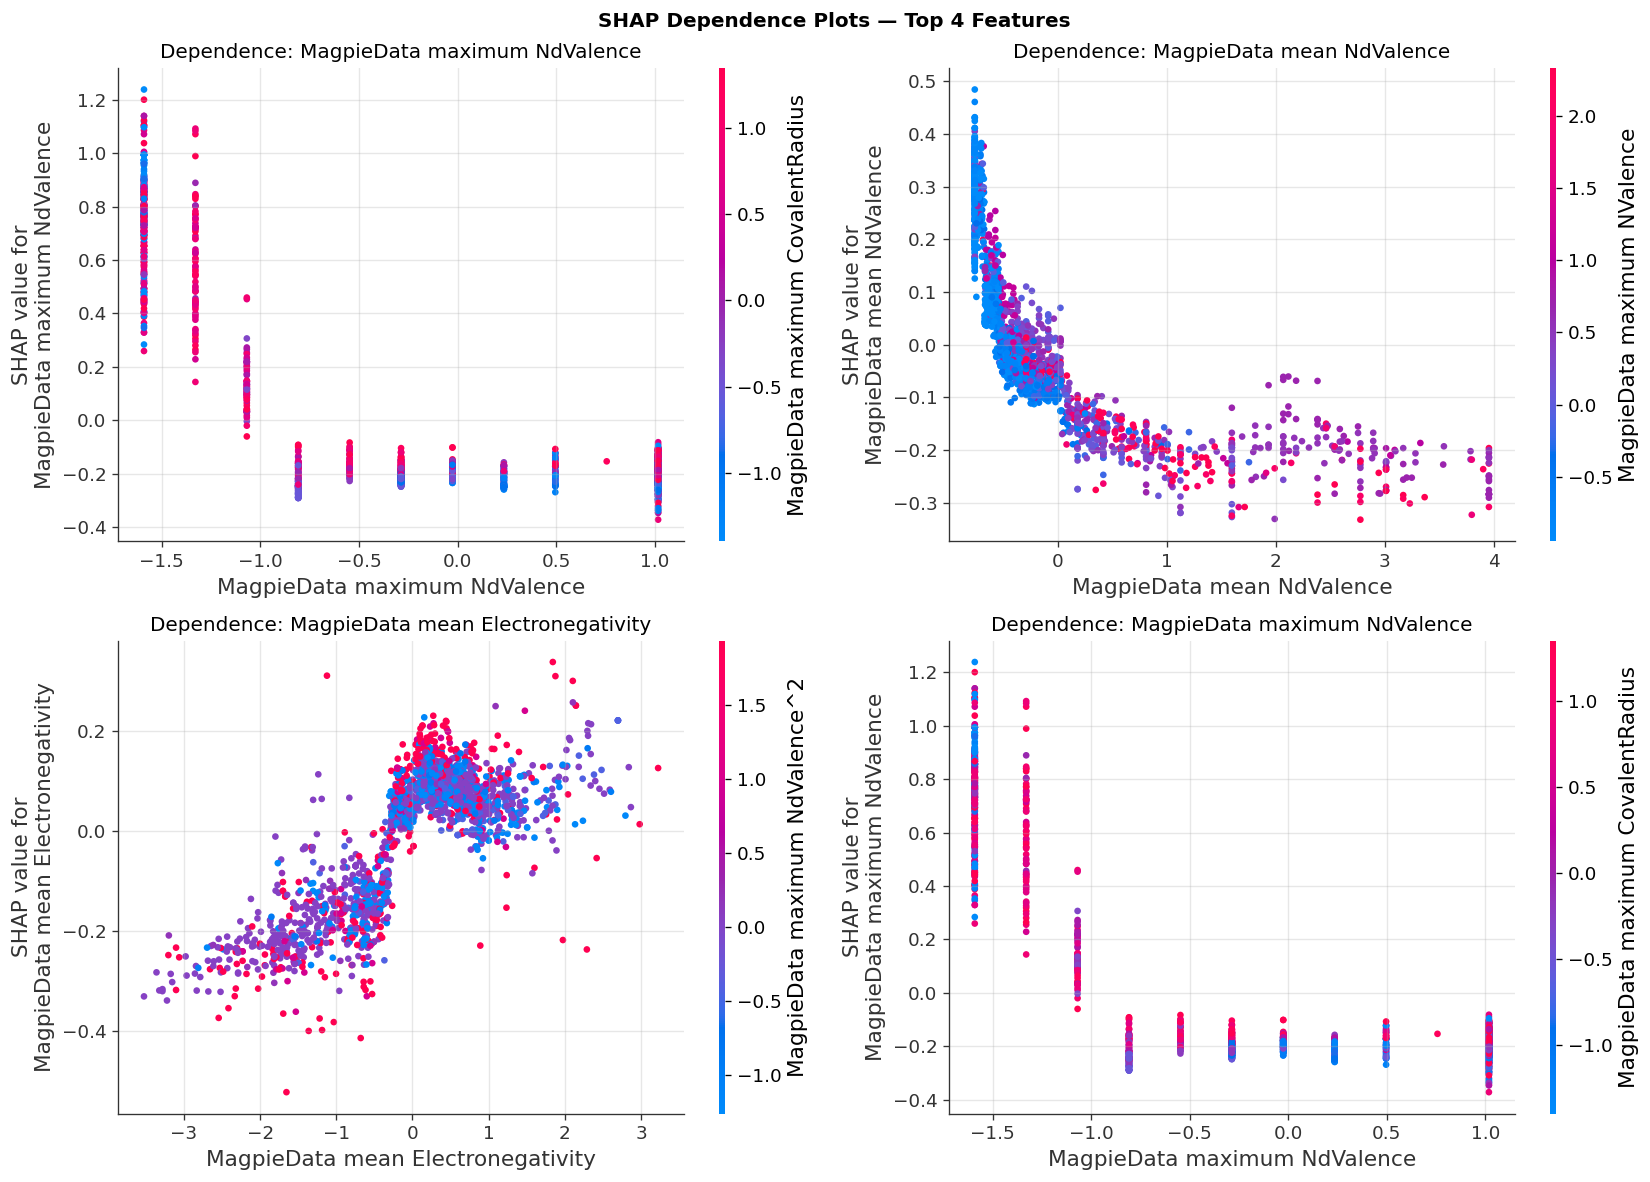

In [ ]:
# 13B — Dependence plots for top 4 SHAP features
top4 = [feat_shap[i] for i in np.argsort(shap_imp)[::-1][:4]]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top4):
    plt.sca(ax)
    shap.dependence_plot(feat, shap_values, Xte_shap_s, feature_names=feat_shap, ax=ax, show=False)
    ax.set_title(f'Dependence: {feat}')
plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML Project/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 13D — Validate: SHAP top-10 vs MI top-10 overlap
mi_top10   = set(mi_df.head(10)['feature'].tolist())
shap_top10 = set([feat_shap[i] for i in np.argsort(shap_imp)[::-1][:10]])
overlap    = mi_top10 & shap_top10

print('MI top-10:  ', mi_top10)
print('SHAP top-10:', shap_top10)
print(f'\nOverlap: {len(overlap)}/10 features')
if len(overlap) >= 7:
    print('HIGH overlap — MI selection validated. The right features were kept.')
elif len(overlap) >= 4:
    print('MODERATE overlap — SHAP found some non-linear patterns MI missed. Consider expanding MI top-K.')
else:
    print('LOW overlap — SHAP is capturing patterns MI missed. Revisit feature selection strategy.')

MI top-10:   {'MagpieData mean NdValence', 'MagpieData minimum GSvolume_pa', 'MagpieData mode MendeleevNumber', 'MagpieData maximum Number', 'MagpieData mode Number', 'MagpieData range CovalentRadius', 'MagpieData maximum MeltingT', 'MagpieData avg_dev NdValence', 'MagpieData mode Electronegativity', 'MagpieData maximum NdValence'}
SHAP top-10: {'MagpieData maximum NValence', 'MagpieData mean NdValence', 'MagpieData mean Electronegativity', 'MagpieData maximum NdValence', 'MagpieData avg_dev NValence', 'MagpieData mean SpaceGroupNumber', 'MagpieData maximum MeltingT MagpieData maximum NdValence', 'MagpieData maximum CovalentRadius', 'MagpieData mode MeltingT MagpieData mode Electronegativity'}

Overlap: 2/10 features
LOW overlap — SHAP is capturing patterns MI missed. Revisit feature selection strategy.


---
## 14. Final Summary & Insights

In [ ]:
# Compile all tuned results
tuned_results = pd.DataFrame([
    {'Model': 'Ridge',   'Feature Set': RIDGE_FEATURE_SET,
     'Train MAE': ridge_train_mae, 'Test MAE': ridge_test_mae, 'Test R2': ridge_test_r2,
     'Overfit Gap': ridge_gap, 'Best Params': f'alpha={RIDGE_BEST_ALPHA:.2f}'},
    {'Model': 'RF',      'Feature Set': RF_FEATURE_SET,
     'Train MAE': rf_train_mae,    'Test MAE': rf_test_mae,    'Test R2': rf_test_r2,
     'Overfit Gap': rf_gap,       'Best Params': str(RF_BEST)},
    {'Model': 'GBM',     'Feature Set': GBM_FEATURE_SET,
     'Train MAE': gbm_train_mae,   'Test MAE': gbm_test_mae,   'Test R2': gbm_test_r2,
     'Overfit Gap': gbm_gap,      'Best Params': str(GBM_BEST)},
    {'Model': 'XGBoost', 'Feature Set': XGB_FEATURE_SET,
     'Train MAE': xgb_train_mae,   'Test MAE': xgb_test_mae,   'Test R2': xgb_test_r2,
     'Overfit Gap': xgb_gap,      'Best Params': str(XGB_BEST)},
]).sort_values('Test MAE').reset_index(drop=True)

tuned_results['Status'] = tuned_results['Overfit Gap'].apply(
    lambda g: 'OVERFIT' if g < -0.05 else ('UNDERFIT' if g > 0.1 else 'GOOD FIT'))

print(tuned_results[['Model','Feature Set','Train MAE','Test MAE','Test R2','Overfit Gap','Status']].to_string(
    index=False, float_format='{:.4f}'.format))

  Model Feature Set  Train MAE  Test MAE  Test R2  Overfit Gap   Status
XGBoost        full     0.3461    0.4418   0.8115      -0.0956  OVERFIT
    GBM    Selected     0.4665    0.5133   0.7603      -0.0468 GOOD FIT
     RF    Selected     0.5443    0.5777   0.7025      -0.0334 GOOD FIT
  Ridge    Selected     0.8623    0.8557   0.4393       0.0066 GOOD FIT


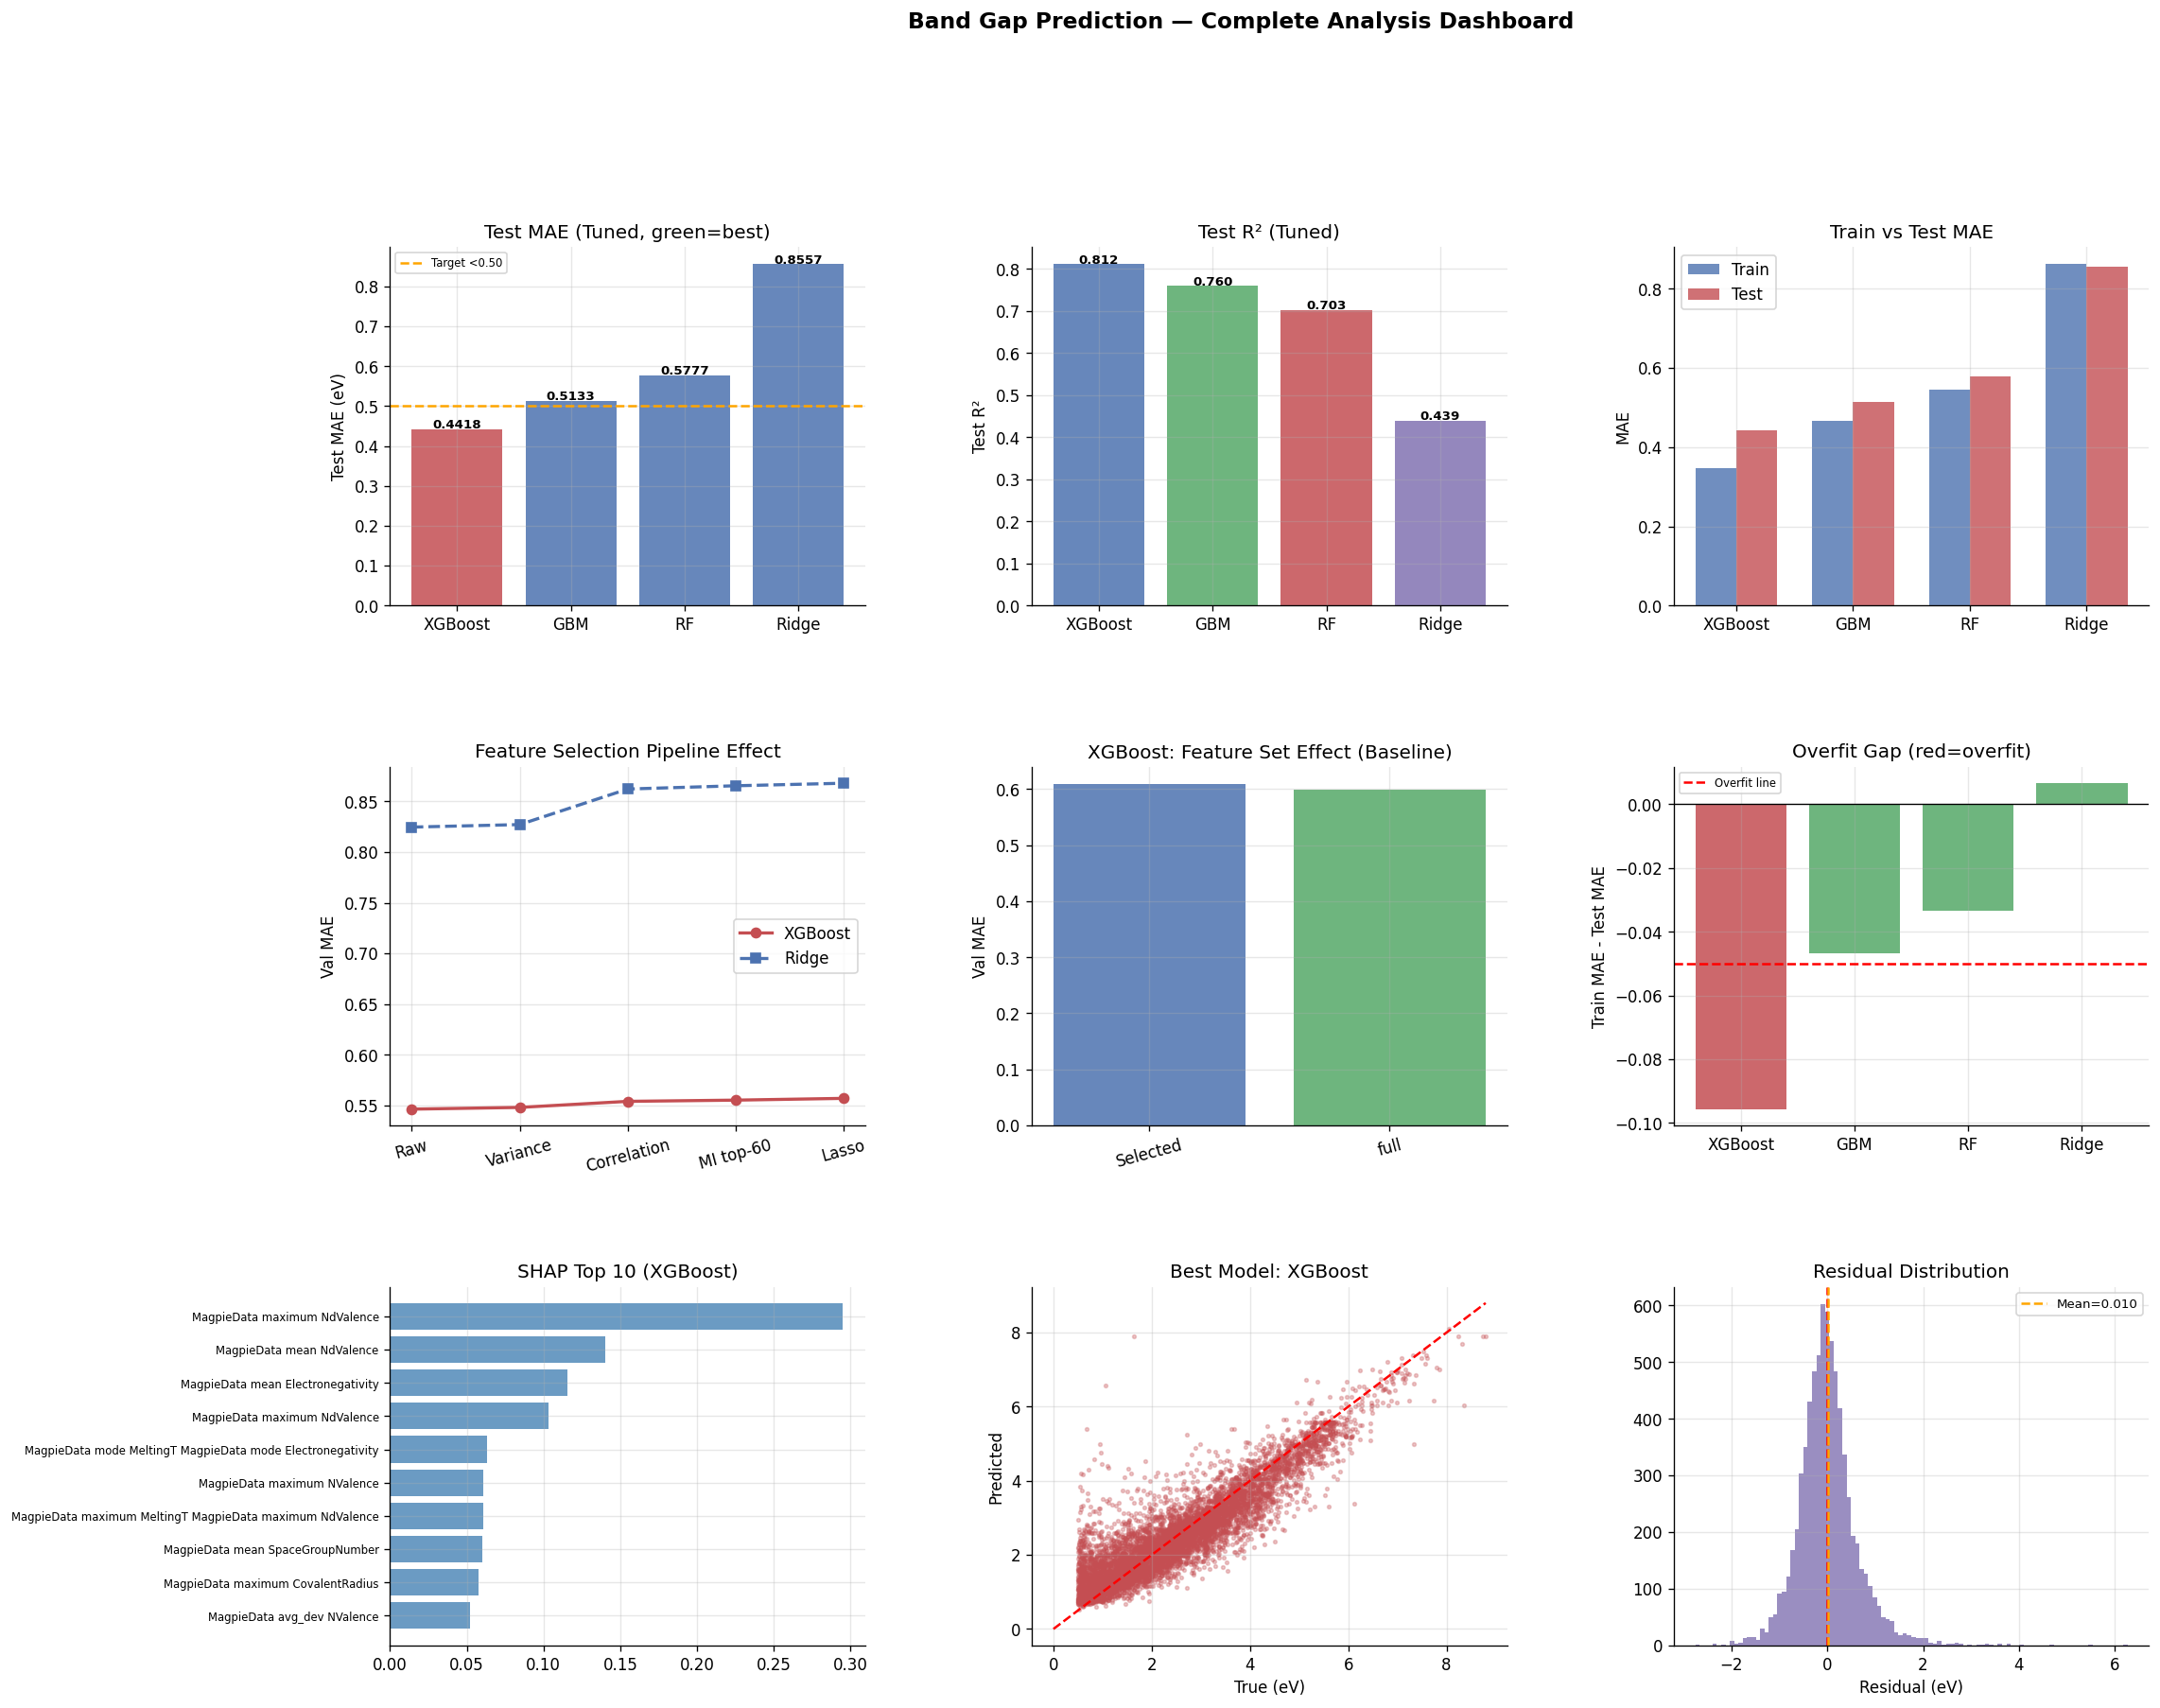

In [ ]:
# Dashboard
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1 — Test MAE
ax1 = fig.add_subplot(gs[0, 0])
best_mae = tuned_results['Test MAE'].min()
col_bar  = [COLORS[2] if v == best_mae else COLORS[0] for v in tuned_results['Test MAE']]
ax1.bar(tuned_results['Model'], tuned_results['Test MAE'], color=col_bar, alpha=0.85)
ax1.axhline(0.50, color='orange', linestyle='--', label='Target <0.50')
for i, v in enumerate(tuned_results['Test MAE']):
    ax1.text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
ax1.set_ylabel('Test MAE (eV)'); ax1.set_title('Test MAE (Tuned, green=best)'); ax1.legend(fontsize=7)

# 2 — R²
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(tuned_results['Model'], tuned_results['Test R2'], color=COLORS[:5], alpha=0.85)
for i, v in enumerate(tuned_results['Test R2']):
    ax2.text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax2.set_ylabel('Test R²'); ax2.set_title('Test R² (Tuned)')

# 3 — Train vs Test MAE
ax3 = fig.add_subplot(gs[0, 2])
x = np.arange(len(tuned_results)); w = 0.35
ax3.bar(x-w/2, tuned_results['Train MAE'], w, label='Train', color=COLORS[0], alpha=0.8)
ax3.bar(x+w/2, tuned_results['Test MAE'],  w, label='Test',  color=COLORS[2], alpha=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(tuned_results['Model'])
ax3.set_ylabel('MAE'); ax3.set_title('Train vs Test MAE'); ax3.legend()

# 4 — Selection pipeline
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(sel_df['stage'], sel_df['xgb_mae'],   'o-', color=COLORS[2], label='XGBoost', linewidth=2)
ax4.plot(sel_df['stage'], sel_df['ridge_mae'], 's--', color=COLORS[0], label='Ridge',   linewidth=2)
ax4.set_ylabel('Val MAE'); ax4.set_title('Feature Selection Pipeline Effect'); ax4.legend()
ax4.tick_params(axis='x', rotation=15)

# 5 — Feature set effect (XGBoost baseline)
ax5 = fig.add_subplot(gs[1, 1])
xgb_b = baseline_df[baseline_df['Model']=='XGBoost'].set_index('Feature Set')['Val MAE']
ax5.bar(xgb_b.index, xgb_b.values, color=COLORS[:len(xgb_b)], alpha=0.85)
ax5.set_ylabel('Val MAE'); ax5.set_title('XGBoost: Feature Set Effect (Baseline)')
ax5.tick_params(axis='x', rotation=15)

# 6 — Overfit gap
ax6 = fig.add_subplot(gs[1, 2])
gap_c = [COLORS[2] if g < -0.05 else COLORS[1] for g in tuned_results['Overfit Gap']]
ax6.bar(tuned_results['Model'], tuned_results['Overfit Gap'], color=gap_c, alpha=0.85)
ax6.axhline(0, color='black', linewidth=0.8)
ax6.axhline(-0.05, color='red', linestyle='--', label='Overfit line')
ax6.set_ylabel('Train MAE - Test MAE'); ax6.set_title('Overfit Gap (red=overfit)'); ax6.legend(fontsize=7)

# 7 — SHAP top 10
ax7 = fig.add_subplot(gs[2, 0])
top10 = np.argsort(shap_imp)[::-1][:10]
ax7.barh(range(10), shap_imp[top10][::-1], color='steelblue', alpha=0.8)
ax7.set_yticks(range(10)); ax7.set_yticklabels([feat_shap[i] for i in top10][::-1], fontsize=7)
ax7.set_title('SHAP Top 10 (XGBoost)')

# 8 — Prediction scatter (best model)
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(y_test, pred_x, alpha=0.3, s=5, color=COLORS[2])
lims = [0, max(y_test.max(), pred_x.max())]
ax8.plot(lims, lims, 'r--')
ax8.set_xlabel('True (eV)'); ax8.set_ylabel('Predicted'); ax8.set_title(f'Best Model: {tuned_results.iloc[0]["Model"]}')

# 9 — Residual distribution
ax9 = fig.add_subplot(gs[2, 2])
resid = pred_x - y_test
ax9.hist(resid, bins=100, color=COLORS[3], alpha=0.8, edgecolor='none')
ax9.axvline(0, color='red', linestyle='--')
ax9.axvline(resid.mean(), color='orange', linestyle='--', label=f'Mean={resid.mean():.3f}')
ax9.set_xlabel('Residual (eV)'); ax9.set_title('Residual Distribution'); ax9.legend(fontsize=8)

plt.suptitle('Band Gap Prediction — Complete Analysis Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/drive/MyDrive/ML Project/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_row = tuned_results.iloc[0]
overfit_m  = tuned_results[tuned_results['Status']=='OVERFIT']['Model'].tolist()
underfit_m = tuned_results[tuned_results['Status']=='UNDERFIT']['Model'].tolist()
goodfit_m  = tuned_results[tuned_results['Status']=='GOOD FIT']['Model'].tolist()

xgb_A = baseline_df[(baseline_df['Model']=='XGBoost')&(baseline_df['Feature Set']=='A_selected')]['Val MAE'].values
xgb_C = baseline_df[(baseline_df['Model']=='XGBoost')&(baseline_df['Feature Set']=='C_full')]['Val MAE'].values

shap_top10_f = set([feat_shap[i] for i in np.argsort(shap_imp)[::-1][:10]])
overlap      = set(mi_df.head(10)['feature'].tolist()) & shap_top10_f

print('=' * 75)
print('                    FINAL ANALYSIS SUMMARY')
print('=' * 75)

print('\n── DATASET ──────────────────────────────────────────────────────────────')
print(f'  Total usable samples   : {len(df_clean):,}')
print(f'  Train/Val/Test split   : {X_train_raw.shape[0]:,} / {X_val_raw.shape[0]:,} / {X_test_raw.shape[0]:,}')
print(f'  Metals (gap=0)         : {(y==0).sum():,} ({100*(y==0).mean():.1f}%)')
print(f'  Insulators             : {(y>0).sum():,} ({100*(y>0).mean():.1f}%)')
print(f'  Structural note        : Metal spike at gap=0 is a known regression challenge.')
print(f'                           A 2-stage model (classify→regress) is the proper fix.')

print('\n── FEATURE SELECTION ────────────────────────────────────────────────────')
for _, row in sel_df.iterrows():
    print(f'  {row["stage"]:22s}: {int(row["n_features"]):3d} features | XGB Val MAE = {row["xgb_mae"]:.4f}')
raw_xgb  = sel_df[sel_df['stage']=='Raw']['xgb_mae'].values[0]
final_xgb = sel_df.iloc[-1]['xgb_mae']
if final_xgb > raw_xgb * 1.02:
    print(f'  ⚠ Selection degraded XGB slightly ({raw_xgb:.4f}→{final_xgb:.4f}). Loosen MI cutoff or Lasso alpha.')
else:
    print(f'  ✓ Selection maintained or improved performance. Pipeline is valid.')

print('\n── FEATURE ENGINEERING ─────────────────────────────────────────────────')
if len(xgb_A) > 0 and len(xgb_C) > 0:
    delta = xgb_A[0] - xgb_C[0]
    print(f'  A (selected only) val MAE     : {xgb_A[0]:.4f}')
    print(f'  C (full engineered) val MAE   : {xgb_C[0]:.4f}')
    verdict = 'HELPED' if delta > 0.002 else ('NEUTRAL' if abs(delta) <= 0.002 else 'HURT')
    print(f'  Engineering verdict           : {verdict} (Δ={delta:+.4f})')
    if verdict in ['NEUTRAL', 'HURT']:
        print(f'  Polynomial/ratio features likely added noise.')
        print(f'  Physics features (Set B) are more defensible — check Set B vs A separately.')

print('\n── MODEL RESULTS (TEST SET, TUNED) ──────────────────────────────────────')
for _, row in tuned_results.iterrows():
    print(f'  {row["Model"]:10s} | MAE={row["Test MAE"]:.4f} | R²={row["Test R2"]:.4f} | Gap={row["Overfit Gap"]:+.4f} | {row["Status"]}')

print('\n── FIT DIAGNOSIS ────────────────────────────────────────────────────────')
print(f'  Good fit  : {goodfit_m  if goodfit_m  else "None"}')
print(f'  Overfit   : {overfit_m  if overfit_m  else "None"}')
print(f'  Underfit  : {underfit_m if underfit_m else "None"}')
if overfit_m:
    print(f'  Fix: increase regularization, reduce max_depth, use stronger L1/L2')
if underfit_m:
    print(f'  Fix: richer feature engineering or more complex model')

print('\n── SHAP VALIDATION ──────────────────────────────────────────────────────')
top5_shap = [feat_shap[i] for i in np.argsort(shap_imp)[::-1][:5]]
for i, f in enumerate(top5_shap, 1):
    print(f'  {i}. {f}')
print(f'  MI-SHAP overlap (top 10): {len(overlap)}/10')
if len(overlap) >= 7:
    print('  ✓ HIGH — MI selection confirmed by SHAP')
else:
    print('  ⚠ LOW — SHAP found patterns MI missed. Expand MI K or engineer SHAP-guided features.')

print('\n── BEST MODEL ───────────────────────────────────────────────────────────')
print(f'  Model      : {best_row["Model"]} on {best_row["Feature Set"]}')
print(f'  Test MAE   : {best_row["Test MAE"]:.4f} eV')
print(f'  Test R²    : {best_row["Test R2"]:.4f}')
print(f'  Overfit Gap: {best_row["Overfit Gap"]:+.4f}')
reached = 'YES ✓' if best_row['Test MAE'] < 0.50 else 'NO ✗'
print(f'  <0.50 target: {reached}')

print('\n── BENCHMARKS ───────────────────────────────────────────────────────────')
print('  GNN (3D crystal structure) : ~0.31 eV  (uses structural info we do not have)')
print('  Composition-only target    : <0.50 eV')
print('  DFT vs experiment error    : 0.5–1.0 eV systematic offset')

print('\n── REMAINING IMPROVEMENT PATHS ─────────────────────────────────────────')
print('  1. Two-stage: classify metals first, regress insulators separately')
print('  2. Feature engineering guided by SHAP top features (not blind polynomial)')
print('  3. Ensemble XGBoost + GBM with weighted average')
print('  4. Check if learning curves are still descending — more data if so')
print('  5. Add structural features if structure data is available')
print('=' * 75)

tuned_results.to_csv('/content/drive/MyDrive/ML Project/tuned_model_results.csv', index=False)
print('\nSaved: tuned_model_results.csv | All plots saved to Google Drive')

                    FINAL ANALYSIS SUMMARY

── DATASET ──────────────────────────────────────────────────────────────
  Total usable samples   : 49,476
  Train/Val/Test split   : 34,632 / 7,422 / 7,422
  Metals (gap=0)         : 0 (0.0%)
  Insulators             : 49,476 (100.0%)
  Structural note        : Metal spike at gap=0 is a known regression challenge.
                           A 2-stage model (classify→regress) is the proper fix.

── FEATURE SELECTION ────────────────────────────────────────────────────
  Raw                   : 132 features | XGB Val MAE = 0.5463
  Variance              : 112 features | XGB Val MAE = 0.5480
  Correlation           :  64 features | XGB Val MAE = 0.5540
  MI top-60             :  60 features | XGB Val MAE = 0.5552
  Lasso                 :  46 features | XGB Val MAE = 0.5569
  ✓ Selection maintained or improved performance. Pipeline is valid.

── FEATURE ENGINEERING ─────────────────────────────────────────────────

── MODEL RESULTS (TEST SET, 

---

## How to Read the Results

| What you see | What it means | What to do |
|---|---|---|
| Train MAE << Test MAE (large negative gap) | Overfitting | Increase regularization, reduce tree depth |
| Both Train and Test MAE high | Underfitting | Better features, more complex model |
| Test MAE > 0.50 eV | Below competitive threshold | Try two-stage model, SHAP-guided features |
| CV curve flat at 70% data | Not data-limited | Focus on model/features |
| CV curve still falling at 100% | Data-limited | More samples would help |
| SHAP-MI overlap < 7/10 | Selection missed patterns | Expand MI K or add SHAP-guided features |
| Engineering set C worse than A | Polynomial/ratio = noise | Drop them, keep physics features only |